<a href="https://colab.research.google.com/github/squistanchala-ai/Matematicas_Discretas_proyecto/blob/main/DiscretasProyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==========================================================
# BLOQUE 1
# GENERACIÓN DE SURTIDOS DE ESLABONES
# CON IDENTIFICADORES Y PUERTOS DE CONEXIÓN
# ==========================================================

# ----------------------------------------------------------
# DATOS DEL MECANISMO
# ----------------------------------------------------------

n = 8       # Número total de eslabones
GDL = 1     # Grados de libertad

# Grado máximo considerado para un eslabón
Grado_Max_eslabon = n // 2

# Número de juntas obtenido mediante la ecuación de movilidad
numerador_juntas = 3 * (n - 1) - GDL

# Para mecanismos planos con pares inferiores:
# GDL = 3(n - 1) - 2J
if numerador_juntas % 2 != 0:
    raise ValueError(
        "Los valores de n y GDL no producen un número entero de juntas."
    )

J = numerador_juntas // 2

# Grados posibles: binarios, ternarios, etc.
eslabones_grados = list(range(2, Grado_Max_eslabon + 1))

# Aquí se almacenan todos los surtidos válidos
surtidos_encontrados = []


# ==========================================================
# FUNCIÓN PARA CREAR ESLABONES Y PUERTOS
# ==========================================================

def crear_eslabones(grados_links):
    """
    Crea una lista de eslabones a partir de una secuencia de grados.

    Cada eslabón contiene:
        - id
        - grado
        - puertos

    Cada puerto contiene:
        - id_local: posición dentro del eslabón
        - id_global: identificador único dentro del surtido
        - ocupado: indica si ya participa en una junta
        - conectado_a: información de la conexión futura
    """

    links = []
    id_global_puerto = 1

    for id_eslabon, grado in enumerate(grados_links, start=1):

        puertos = []

        for id_local in range(1, grado + 1):

            puerto = {
                "id_local": id_local,
                "id_global": id_global_puerto,
                "ocupado": False,
                "conectado_a": None,
            }

            puertos.append(puerto)
            id_global_puerto += 1

        eslabon = {
            "id": id_eslabon,
            "grado": grado,
            "puertos": puertos,
        }

        links.append(eslabon)

    return links


# ==========================================================
# BACKTRACKING CON PODA FUERTE
# ==========================================================

def resolver(
    idx=0,
    solucion=None,
    barras_actuales=0,
    nodos_actuales=0,
):
    """
    Resuelve las ecuaciones diofánticas:

        sum(x_g) = n
        sum(g * x_g) = 2J

    donde x_g es la cantidad de eslabones de grado g.
    """

    if solucion is None:
        solucion = []

    # ------------------------------------------------------
    # PODAS BÁSICAS
    # ------------------------------------------------------

    if barras_actuales > n:
        return

    if nodos_actuales > 2 * J:
        return

    # ------------------------------------------------------
    # CASO BASE
    # ------------------------------------------------------

    if idx == len(eslabones_grados):

        if barras_actuales == n and nodos_actuales == 2 * J:

            # Conteo grado -> cantidad
            conteo = {
                grado: cantidad
                for grado, cantidad in zip(
                    eslabones_grados,
                    solucion,
                )
            }

            # Lista de grados individuales
            # Ejemplo: [2, 2, 2, 2, 3, 3]
            grados_links = []

            for grado, cantidad in conteo.items():
                grados_links.extend([grado] * cantidad)

            grados_links.sort()

            # Crear eslabones y sus puertos
            links = crear_eslabones(grados_links)

            # --------------------------------------------------
            # VERIFICACIONES
            # --------------------------------------------------

            numero_eslabones = len(links)

            suma_grados = sum(
                link["grado"]
                for link in links
            )

            numero_puertos = sum(
                len(link["puertos"])
                for link in links
            )

            assert numero_eslabones == n
            assert suma_grados == 2 * J
            assert numero_puertos == 2 * J

            # Guardar toda la información del surtido
            surtidos_encontrados.append(
                {
                    "conteo": conteo,
                    "grados_links": grados_links,
                    "links": links,
                    "numero_eslabones": numero_eslabones,
                    "numero_juntas": J,
                    "numero_puertos": numero_puertos,
                }
            )

        return

    # ------------------------------------------------------
    # EXPLORACIÓN DEL GRADO ACTUAL
    # ------------------------------------------------------

    grado = eslabones_grados[idx]

    barras_restantes = n - barras_actuales

    for cantidad in range(barras_restantes + 1):

        nuevas_barras = barras_actuales + cantidad
        nuevos_nodos = nodos_actuales + cantidad * grado

        # Poda inmediata si ya se excede el objetivo
        if nuevos_nodos > 2 * J:
            continue

        barras_por_asignar = n - nuevas_barras

        # --------------------------------------------------
        # PODA FUERTE
        # --------------------------------------------------

        if idx + 1 < len(eslabones_grados):
            grado_minimo_restante = eslabones_grados[idx + 1]
            grado_maximo_restante = eslabones_grados[-1]
        else:
            # Ya no quedan grados para asignar
            grado_minimo_restante = 0
            grado_maximo_restante = 0

        nodos_minimos = (
            nuevos_nodos
            + barras_por_asignar * grado_minimo_restante
        )

        nodos_maximos = (
            nuevos_nodos
            + barras_por_asignar * grado_maximo_restante
        )

        # El objetivo no puede alcanzarse desde esta rama
        if 2 * J < nodos_minimos:
            continue

        if 2 * J > nodos_maximos:
            continue

        resolver(
            idx=idx + 1,
            solucion=solucion + [cantidad],
            barras_actuales=nuevas_barras,
            nodos_actuales=nuevos_nodos,
        )


# ==========================================================
# EJECUCIÓN
# ==========================================================

resolver()


# ==========================================================
# RESULTADOS GENERALES
# ==========================================================

print("=" * 70)
print("GENERADOR DE SURTIDOS DE ESLABONES")
print("=" * 70)

print(f"Número de eslabones       : {n}")
print(f"Grados de libertad        : {GDL}")
print(f"Número de juntas          : {J}")
print(f"Grados considerados       : {eslabones_grados}")
print(f"Puertos requeridos        : {2 * J}")

print()
print(f"Total de surtidos encontrados: {len(surtidos_encontrados)}")
print("=" * 70)


# ==========================================================
# IMPRESIÓN DETALLADA DE CADA SURTIDO
# ==========================================================

for indice_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    print(f"\nSURTIDO {indice_surtido}")
    print("-" * 70)

    # ------------------------------------------------------
    # Conteo por grado
    # ------------------------------------------------------

    print("Conteo de eslabones por grado:")

    for grado, cantidad in surtido["conteo"].items():
        print(f"  Grado {grado}: {cantidad}")

    # ------------------------------------------------------
    # Lista de grados
    # ------------------------------------------------------

    print("\nSecuencia de grados:")

    print(f"  {surtido['grados_links']}")

    # ------------------------------------------------------
    # Información general
    # ------------------------------------------------------

    print("\nInformación del surtido:")

    print(
        f"  Número de eslabones : "
        f"{surtido['numero_eslabones']}"
    )

    print(
        f"  Número de juntas    : "
        f"{surtido['numero_juntas']}"
    )

    print(
        f"  Número de puertos   : "
        f"{surtido['numero_puertos']}"
    )

    # ------------------------------------------------------
    # Eslabones y puertos
    # ------------------------------------------------------

    print("\nEslabones y puertos disponibles:")

    for link in surtido["links"]:

        print(
            f"\n  Eslabón {link['id']} "
            f"(grado {link['grado']})"
        )

        for puerto in link["puertos"]:

            estado = (
                "ocupado"
                if puerto["ocupado"]
                else "libre"
            )

            print(
                f"    Puerto local {puerto['id_local']} | "
                f"Puerto global {puerto['id_global']} | "
                f"Estado: {estado} | "
                f"Conectado a: {puerto['conectado_a']}"
            )

    print("\n" + "=" * 70)

GENERADOR DE SURTIDOS DE ESLABONES
Número de eslabones       : 8
Grados de libertad        : 1
Número de juntas          : 10
Grados considerados       : [2, 3, 4]
Puertos requeridos        : 20

Total de surtidos encontrados: 3

SURTIDO 1
----------------------------------------------------------------------
Conteo de eslabones por grado:
  Grado 2: 4
  Grado 3: 4
  Grado 4: 0

Secuencia de grados:
  [2, 2, 2, 2, 3, 3, 3, 3]

Información del surtido:
  Número de eslabones : 8
  Número de juntas    : 10
  Número de puertos   : 20

Eslabones y puertos disponibles:

  Eslabón 1 (grado 2)
    Puerto local 1 | Puerto global 1 | Estado: libre | Conectado a: None
    Puerto local 2 | Puerto global 2 | Estado: libre | Conectado a: None

  Eslabón 2 (grado 2)
    Puerto local 1 | Puerto global 3 | Estado: libre | Conectado a: None
    Puerto local 2 | Puerto global 4 | Estado: libre | Conectado a: None

  Eslabón 3 (grado 2)
    Puerto local 1 | Puerto global 5 | Estado: libre | Conectado a: N

In [5]:
# ==========================================================
# BLOQUE 2
# GENERACIÓN DE CONEXIONES MEDIANTE BACKTRACKING
# ==========================================================

from copy import deepcopy
from itertools import combinations


# ----------------------------------------------------------
# CONFIGURACIÓN DEL BLOQUE 3
# ----------------------------------------------------------

# None significa que se generan todos los grafos candidatos.
# Para hacer pruebas se puede usar, por ejemplo:
# MAX_CANDIDATOS_POR_SURTIDO = 100
MAX_CANDIDATOS_POR_SURTIDO = None

# Cantidad máxima de grafos que se imprimirán por surtido.
# Todos los grafos se generan y almacenan, aunque no se impriman.
LIMITE_GRAFOS_A_MOSTRAR = 10


# ==========================================================
# VERIFICACIÓN DE SECUENCIA GRÁFICA
# CRITERIO DE ERDŐS-GALLAI
# ==========================================================

def es_secuencia_grafica(grados):
    """
    Verifica si una secuencia de enteros puede ser la secuencia
    de grados de un grafo simple.

    Se emplea el criterio de Erdős-Gallai.

    Parámetros
    ----------
    grados : list[int]
        Secuencia de grados que se desea verificar.

    Retorna
    -------
    bool
        True si la secuencia es gráfica.
        False en caso contrario.
    """

    # Eliminar ceros y ordenar de mayor a menor
    secuencia = sorted(
        [grado for grado in grados if grado > 0],
        reverse=True,
    )

    numero_vertices = len(secuencia)

    # La secuencia vacía corresponde a un grafo sin aristas
    if numero_vertices == 0:
        return True

    # Ningún grado puede ser negativo
    if any(grado < 0 for grado in secuencia):
        return False

    # En un grafo simple con m vértices:
    # grado máximo <= m - 1
    if secuencia[0] >= numero_vertices:
        return False

    # La suma de los grados debe ser par
    if sum(secuencia) % 2 != 0:
        return False

    # Verificación de las desigualdades de Erdős-Gallai
    for k in range(1, numero_vertices + 1):

        lado_izquierdo = sum(secuencia[:k])

        lado_derecho = (
            k * (k - 1)
            + sum(
                min(grado, k)
                for grado in secuencia[k:]
            )
        )

        if lado_izquierdo > lado_derecho:
            return False

    return True


# ==========================================================
# CREACIÓN DE LA MATRIZ DE ADYACENCIA
# ==========================================================

def copiar_matriz(matriz):
    """
    Crea una copia independiente de una matriz.
    """

    return [
        fila.copy()
        for fila in matriz
    ]


# ==========================================================
# ASIGNACIÓN DE PUERTOS A LAS JUNTAS
# ==========================================================

def buscar_primer_puerto_libre(eslabon):
    """
    Busca el primer puerto libre de un eslabón.

    Retorna el diccionario correspondiente al puerto.

    Lanza un error si no existen puertos disponibles.
    """

    for puerto in eslabon["puertos"]:

        if not puerto["ocupado"]:
            return puerto

    raise RuntimeError(
        f"El eslabón {eslabon['id']} "
        "no tiene puertos disponibles."
    )


def materializar_conexiones(surtido, aristas):
    """
    Convierte una lista de aristas entre eslabones en conexiones
    concretas entre puertos.

    Cada arista consume:
        - un puerto del primer eslabón;
        - un puerto del segundo eslabón.

    Los eslabones originales del surtido no son modificados.
    Se crea una copia independiente.

    Parámetros
    ----------
    surtido : dict
        Surtido sobre el cual se construye el mecanismo.

    aristas : list[tuple[int, int]]
        Lista de conexiones. Los identificadores de los eslabones
        comienzan en 1.

    Retorna
    -------
    tuple
        links_conectados, juntas
    """

    # Copia profunda para no modificar el surtido original
    links_conectados = deepcopy(surtido["links"])

    # Acceso rápido:
    # id del eslabón -> objeto del eslabón
    eslabones_por_id = {
        eslabon["id"]: eslabon
        for eslabon in links_conectados
    }

    juntas = []

    for id_junta, (id_eslabon_a, id_eslabon_b) in enumerate(
        aristas,
        start=1,
    ):

        eslabon_a = eslabones_por_id[id_eslabon_a]
        eslabon_b = eslabones_por_id[id_eslabon_b]

        puerto_a = buscar_primer_puerto_libre(eslabon_a)
        puerto_b = buscar_primer_puerto_libre(eslabon_b)

        # Marcar ambos puertos como ocupados
        puerto_a["ocupado"] = True
        puerto_b["ocupado"] = True

        # Guardar información recíproca de la conexión
        puerto_a["conectado_a"] = {
            "junta_id": id_junta,
            "eslabon_id": id_eslabon_b,
            "puerto_local": puerto_b["id_local"],
            "puerto_global": puerto_b["id_global"],
        }

        puerto_b["conectado_a"] = {
            "junta_id": id_junta,
            "eslabon_id": id_eslabon_a,
            "puerto_local": puerto_a["id_local"],
            "puerto_global": puerto_a["id_global"],
        }

        # Registrar la junta completa
        juntas.append(
            {
                "id": id_junta,

                "eslabon_a": id_eslabon_a,
                "puerto_a_local": puerto_a["id_local"],
                "puerto_a_global": puerto_a["id_global"],

                "eslabon_b": id_eslabon_b,
                "puerto_b_local": puerto_b["id_local"],
                "puerto_b_global": puerto_b["id_global"],
            }
        )

    return links_conectados, juntas


# ==========================================================
# VERIFICACIÓN DE UN GRAFO CANDIDATO
# ==========================================================

def verificar_grados_matriz(
    matriz_adyacencia,
    grados_objetivo,
):
    """
    Verifica que la suma de cada fila de la matriz sea igual
    al grado requerido para el eslabón correspondiente.
    """

    grados_obtenidos = [
        sum(fila)
        for fila in matriz_adyacencia
    ]

    return grados_obtenidos == grados_objetivo


# ==========================================================
# GENERADOR DE GRAFOS PARA UN SURTIDO
# ==========================================================

def generar_grafos_candidatos(
    surtido,
    max_candidatos=None,
):
    """
    Genera todos los grafos simples etiquetados que cumplen
    la secuencia de grados de un surtido.

    El algoritmo procesa los eslabones en orden. Para cada eslabón
    selecciona cuáles eslabones posteriores serán sus vecinos.

    Esto garantiza que:
        - no existan auto-conexiones;
        - no existan aristas repetidas;
        - cada grafo etiquetado se genere una sola vez.

    Importante
    ----------
    En este bloque todavía pueden aparecer grafos desconectados.
    La conectividad se verificará en el Bloque 4.

    Parámetros
    ----------
    surtido : dict
        Surtido generado por los bloques anteriores.

    max_candidatos : int | None
        Máximo número de candidatos que se almacenarán.
        Si es None, se generan todos.

    Retorna
    -------
    list[dict]
        Lista de grafos candidatos.
    """

    grados_objetivo = surtido["grados_links"].copy()

    numero_eslabones = surtido["numero_eslabones"]
    numero_juntas_objetivo = surtido["numero_juntas"]

    grafos_candidatos = []

    # ------------------------------------------------------
    # VERIFICACIONES INICIALES
    # ------------------------------------------------------

    if len(grados_objetivo) != numero_eslabones:
        raise ValueError(
            "La cantidad de grados no coincide "
            "con la cantidad de eslabones."
        )

    if sum(grados_objetivo) != 2 * numero_juntas_objetivo:
        raise ValueError(
            "La suma de los grados no coincide con 2J."
        )

    # Comprobación rápida de existencia
    if not es_secuencia_grafica(grados_objetivo):
        return grafos_candidatos

    # Matriz de adyacencia inicialmente vacía
    matriz_adyacencia = [
        [0 for _ in range(numero_eslabones)]
        for _ in range(numero_eslabones)
    ]

    # Las aristas se almacenan usando identificadores desde 1
    aristas_actuales = []

    # ------------------------------------------------------
    # FUNCIÓN RECURSIVA
    # ------------------------------------------------------

    def backtracking(
        indice_actual,
        grados_restantes,
    ):
        """
        Completa las conexiones de los eslabones a partir del
        índice actual.
        """

        # Detener la búsqueda si se alcanzó el límite
        if (
            max_candidatos is not None
            and
            len(grafos_candidatos) >= max_candidatos
        ):
            return

        # Saltar eslabones cuyo grado restante sea cero
        while (
            indice_actual < numero_eslabones
            and
            grados_restantes[indice_actual] == 0
        ):
            indice_actual += 1

        # --------------------------------------------------
        # CASO BASE
        # --------------------------------------------------

        if indice_actual == numero_eslabones:

            if any(
                grado != 0
                for grado in grados_restantes
            ):
                return

            if len(aristas_actuales) != numero_juntas_objetivo:
                return

            if not verificar_grados_matriz(
                matriz_adyacencia,
                grados_objetivo,
            ):
                return

            # Convertir las aristas en conexiones de puertos
            links_conectados, juntas = materializar_conexiones(
                surtido,
                aristas_actuales,
            )

            candidato = {
                "numero": len(grafos_candidatos) + 1,

                "aristas": aristas_actuales.copy(),

                "matriz_adyacencia": copiar_matriz(
                    matriz_adyacencia
                ),

                "juntas": juntas,

                "links": links_conectados,

                # Se determinará en el Bloque 4
                "es_conexo": None,

                # Se determinará en el Bloque 5
                "es_representante_isomorfo": None,
            }

            grafos_candidatos.append(candidato)

            return

        # --------------------------------------------------
        # CONEXIONES NECESARIAS PARA EL ESLABÓN ACTUAL
        # --------------------------------------------------

        conexiones_necesarias = (
            grados_restantes[indice_actual]
        )

        # Solo se conecta con eslabones posteriores.
        # De esta forma ninguna arista se genera dos veces.
        posibles_vecinos = [
            vecino
            for vecino in range(
                indice_actual + 1,
                numero_eslabones,
            )
            if grados_restantes[vecino] > 0
        ]

        # No hay suficientes vecinos disponibles
        if conexiones_necesarias > len(posibles_vecinos):
            return

        # Elegir exactamente tantos vecinos como conexiones
        # necesita el eslabón actual.
        for vecinos_seleccionados in combinations(
            posibles_vecinos,
            conexiones_necesarias,
        ):

            nuevos_grados_restantes = (
                grados_restantes.copy()
            )

            # Después de seleccionar sus vecinos, el eslabón
            # actual queda completamente satisfecho.
            nuevos_grados_restantes[indice_actual] = 0

            seleccion_valida = True

            for vecino in vecinos_seleccionados:

                nuevos_grados_restantes[vecino] -= 1

                if nuevos_grados_restantes[vecino] < 0:
                    seleccion_valida = False
                    break

            if not seleccion_valida:
                continue

            # La suma restante siempre debe ser par
            if sum(nuevos_grados_restantes) % 2 != 0:
                continue

            # --------------------------------------------------
            # PODA POR CAPACIDAD
            # --------------------------------------------------

            numero_vertices_restantes = (
                numero_eslabones
                - indice_actual
                - 1
            )

            if any(
                grado > numero_vertices_restantes - 1
                for grado in nuevos_grados_restantes[
                    indice_actual + 1:
                ]
            ):
                continue

            # --------------------------------------------------
            # PODA POR ERDŐS-GALLAI
            # --------------------------------------------------

            secuencia_restante = nuevos_grados_restantes[
                indice_actual + 1:
            ]

            if not es_secuencia_grafica(
                secuencia_restante
            ):
                continue

            # --------------------------------------------------
            # AGREGAR TEMPORALMENTE LAS ARISTAS
            # --------------------------------------------------

            aristas_agregadas = []

            for vecino in vecinos_seleccionados:

                # En la matriz se trabaja desde cero
                matriz_adyacencia[indice_actual][vecino] = 1
                matriz_adyacencia[vecino][indice_actual] = 1

                # En la lista de aristas los ID comienzan en 1
                arista = (
                    indice_actual + 1,
                    vecino + 1,
                )

                aristas_actuales.append(arista)
                aristas_agregadas.append(arista)

            # Continuar con el siguiente eslabón
            backtracking(
                indice_actual + 1,
                nuevos_grados_restantes,
            )

            # --------------------------------------------------
            # DESHACER LAS ARISTAS
            # --------------------------------------------------

            for vecino in vecinos_seleccionados:

                matriz_adyacencia[indice_actual][vecino] = 0
                matriz_adyacencia[vecino][indice_actual] = 0

            for _ in aristas_agregadas:
                aristas_actuales.pop()

            # Detener si se alcanzó el límite
            if (
                max_candidatos is not None
                and
                len(grafos_candidatos) >= max_candidatos
            ):
                return

    # ------------------------------------------------------
    # INICIAR BACKTRACKING
    # ------------------------------------------------------

    backtracking(
        indice_actual=0,
        grados_restantes=grados_objetivo.copy(),
    )

    return grafos_candidatos


# ==========================================================
# EJECUTAR BLOQUE 3 PARA TODOS LOS SURTIDOS
# ==========================================================

for indice_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    grafos_candidatos = generar_grafos_candidatos(
        surtido=surtido,
        max_candidatos=MAX_CANDIDATOS_POR_SURTIDO,
    )

    # Guardar los resultados dentro del propio surtido
    surtido["grafos_candidatos"] = grafos_candidatos

    surtido["numero_grafos_candidatos"] = len(
        grafos_candidatos
    )


# ==========================================================
# RESULTADOS DEL BLOQUE 3
# ==========================================================

print()
print("=" * 70)
print("BLOQUE 3")
print("GENERACIÓN DE GRAFOS CANDIDATOS")
print("=" * 70)

for indice_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    print(f"\nSURTIDO {indice_surtido}")
    print("-" * 70)

    print(
        f"Secuencia de grados: "
        f"{surtido['grados_links']}"
    )

    print(
        f"Grafos candidatos generados: "
        f"{surtido['numero_grafos_candidatos']}"
    )

    grafos_a_mostrar = surtido["grafos_candidatos"][
        :LIMITE_GRAFOS_A_MOSTRAR
    ]

    for candidato in grafos_a_mostrar:

        print()
        print(
            f"Grafo candidato "
            f"{candidato['numero']}"
        )

        print(
            f"Aristas: "
            f"{candidato['aristas']}"
        )

        print("Matriz de adyacencia:")

        for fila in candidato["matriz_adyacencia"]:

            print(
                "  "
                + " ".join(
                    str(valor)
                    for valor in fila
                )
            )

        print("Juntas y puertos:")

        for junta in candidato["juntas"]:

            print(
                f"  Junta {junta['id']}: "
                f"Eslabón {junta['eslabon_a']} "
                f"[puerto local "
                f"{junta['puerto_a_local']}, "
                f"global "
                f"{junta['puerto_a_global']}]"
                f"  <-->  "
                f"Eslabón {junta['eslabon_b']} "
                f"[puerto local "
                f"{junta['puerto_b_local']}, "
                f"global "
                f"{junta['puerto_b_global']}]"
            )

    numero_no_mostrado = (
        surtido["numero_grafos_candidatos"]
        - len(grafos_a_mostrar)
    )

    if numero_no_mostrado > 0:

        print()
        print(
            f"No se muestran {numero_no_mostrado} "
            "grafos adicionales para evitar una salida extensa."
        )

    print("\n" + "=" * 70)


BLOQUE 3
GENERACIÓN DE GRAFOS CANDIDATOS

SURTIDO 1
----------------------------------------------------------------------
Secuencia de grados: [2, 2, 2, 2, 3, 3, 3, 3]
Grafos candidatos generados: 6057

Grafo candidato 1
Aristas: [(1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (5, 7), (5, 8), (6, 7), (6, 8), (7, 8)]
Matriz de adyacencia:
  0 1 1 0 0 0 0 0
  1 0 1 0 0 0 0 0
  1 1 0 0 0 0 0 0
  0 0 0 0 1 1 0 0
  0 0 0 1 0 0 1 1
  0 0 0 1 0 0 1 1
  0 0 0 0 1 1 0 1
  0 0 0 0 1 1 1 0
Juntas y puertos:
  Junta 1: Eslabón 1 [puerto local 1, global 1]  <-->  Eslabón 2 [puerto local 1, global 3]
  Junta 2: Eslabón 1 [puerto local 2, global 2]  <-->  Eslabón 3 [puerto local 1, global 5]
  Junta 3: Eslabón 2 [puerto local 2, global 4]  <-->  Eslabón 3 [puerto local 2, global 6]
  Junta 4: Eslabón 4 [puerto local 1, global 7]  <-->  Eslabón 5 [puerto local 1, global 9]
  Junta 5: Eslabón 4 [puerto local 2, global 8]  <-->  Eslabón 6 [puerto local 1, global 12]
  Junta 6: Eslabón 5 [puerto local 2, glob

In [6]:
# ==========================================================
# BLOQUE 3
# VALIDACIÓN DE RESTRICCIONES TOPOLÓGICAS
# ==========================================================


# ==========================================================
# CONFIGURACIÓN
# ==========================================================

# Cantidad máxima de grafos válidos que se imprimirán
# por cada surtido.
LIMITE_VALIDOS_A_MOSTRAR = 10

# Si es True, se guardan también los grafos rechazados
# junto con las razones por las que fueron descartados.
GUARDAR_GRAFOS_RECHAZADOS = True


# ==========================================================
# VALIDACIÓN DE LA MATRIZ DE ADYACENCIA
# ==========================================================

def validar_matriz_adyacencia(
    matriz,
    numero_eslabones,
):
    """
    Verifica las propiedades básicas de una matriz de adyacencia
    correspondiente a un grafo simple no dirigido.

    Restricciones:
        - matriz cuadrada;
        - tamaño igual al número de eslabones;
        - elementos binarios;
        - diagonal nula;
        - matriz simétrica.

    Retorna
    -------
    list[str]
        Lista de errores encontrados.
        La lista vacía indica que la matriz es válida.
    """

    errores = []

    # ------------------------------------------------------
    # Verificar tipo general
    # ------------------------------------------------------

    if not isinstance(matriz, list):

        errores.append(
            "La matriz de adyacencia no es una lista."
        )

        return errores

    # ------------------------------------------------------
    # Verificar número de filas
    # ------------------------------------------------------

    if len(matriz) != numero_eslabones:

        errores.append(
            "El número de filas de la matriz no coincide "
            "con el número de eslabones."
        )

        return errores

    # ------------------------------------------------------
    # Verificar que sea cuadrada
    # ------------------------------------------------------

    for indice_fila, fila in enumerate(matriz):

        if not isinstance(fila, list):

            errores.append(
                f"La fila {indice_fila + 1} "
                "no es una lista."
            )

            continue

        if len(fila) != numero_eslabones:

            errores.append(
                f"La fila {indice_fila + 1} "
                "no tiene la longitud correcta."
            )

    # Si no es cuadrada, no es seguro seguir indexando
    if errores:
        return errores

    # ------------------------------------------------------
    # Verificar valores, diagonal y simetría
    # ------------------------------------------------------

    for i in range(numero_eslabones):

        for j in range(numero_eslabones):

            valor = matriz[i][j]

            if valor not in (0, 1):

                errores.append(
                    f"La entrada A[{i + 1},{j + 1}] "
                    f"tiene el valor {valor}; "
                    "solo se permiten 0 y 1."
                )

        if matriz[i][i] != 0:

            errores.append(
                f"El eslabón {i + 1} presenta "
                "una auto-conexión."
            )

    for i in range(numero_eslabones):

        for j in range(i + 1, numero_eslabones):

            if matriz[i][j] != matriz[j][i]:

                errores.append(
                    f"La matriz no es simétrica en "
                    f"A[{i + 1},{j + 1}] y "
                    f"A[{j + 1},{i + 1}]."
                )

    return errores


# ==========================================================
# OBTENER GRADOS DESDE LA MATRIZ
# ==========================================================

def obtener_grados_desde_matriz(matriz):
    """
    Calcula el grado de cada eslabón sumando las filas
    de la matriz de adyacencia.
    """

    return [
        sum(fila)
        for fila in matriz
    ]


# ==========================================================
# OBTENER ARISTAS DESDE LA MATRIZ
# ==========================================================

def obtener_aristas_desde_matriz(matriz):
    """
    Obtiene la lista de aristas de una matriz de adyacencia.

    Los identificadores de los eslabones comienzan en 1.
    """

    numero_eslabones = len(matriz)

    aristas = []

    for i in range(numero_eslabones):

        for j in range(i + 1, numero_eslabones):

            if matriz[i][j] == 1:

                aristas.append(
                    (i + 1, j + 1)
                )

    return aristas


# ==========================================================
# VERIFICACIÓN DE CONECTIVIDAD
# ==========================================================

def es_grafo_conexo(matriz):
    """
    Determina si todos los eslabones pertenecen a una única
    componente conexa.

    Se utiliza una búsqueda en profundidad, DFS.
    """

    numero_eslabones = len(matriz)

    if numero_eslabones == 0:
        return False

    visitados = set()
    pila = [0]

    while pila:

        vertice_actual = pila.pop()

        if vertice_actual in visitados:
            continue

        visitados.add(vertice_actual)

        for vecino, conectado in enumerate(
            matriz[vertice_actual]
        ):

            if (
                conectado == 1
                and
                vecino not in visitados
            ):

                pila.append(vecino)

    return len(visitados) == numero_eslabones


# ==========================================================
# COMPONENTES CONEXAS
# ==========================================================

def obtener_componentes_conexas(matriz):
    """
    Obtiene las componentes conexas del grafo.

    Los identificadores de los eslabones comienzan en 1.
    """

    numero_eslabones = len(matriz)

    visitados = set()
    componentes = []

    for vertice_inicial in range(numero_eslabones):

        if vertice_inicial in visitados:
            continue

        componente = []
        pila = [vertice_inicial]

        while pila:

            vertice_actual = pila.pop()

            if vertice_actual in visitados:
                continue

            visitados.add(vertice_actual)

            componente.append(
                vertice_actual + 1
            )

            for vecino, conectado in enumerate(
                matriz[vertice_actual]
            ):

                if (
                    conectado == 1
                    and
                    vecino not in visitados
                ):

                    pila.append(vecino)

        componentes.append(
            sorted(componente)
        )

    return componentes


# ==========================================================
# VALIDACIÓN DE ARISTAS
# ==========================================================

def validar_aristas(
    aristas,
    numero_eslabones,
    numero_juntas_objetivo,
):
    """
    Verifica la lista de aristas almacenada en un candidato.

    Restricciones:
        - cada arista debe tener dos extremos;
        - los identificadores deben ser válidos;
        - no puede haber auto-conexiones;
        - no puede haber aristas duplicadas;
        - debe existir exactamente J aristas.
    """

    errores = []

    if not isinstance(aristas, list):

        errores.append(
            "La lista de aristas no tiene un formato válido."
        )

        return errores

    aristas_normalizadas = []

    for indice, arista in enumerate(
        aristas,
        start=1,
    ):

        if (
            not isinstance(arista, tuple)
            or
            len(arista) != 2
        ):

            errores.append(
                f"La arista {indice} no tiene "
                "el formato (eslabón_a, eslabón_b)."
            )

            continue

        a, b = arista

        if not isinstance(a, int) or not isinstance(b, int):

            errores.append(
                f"La arista {indice} contiene "
                "identificadores no enteros."
            )

            continue

        if not (1 <= a <= numero_eslabones):

            errores.append(
                f"La arista {indice} contiene "
                f"el eslabón inválido {a}."
            )

        if not (1 <= b <= numero_eslabones):

            errores.append(
                f"La arista {indice} contiene "
                f"el eslabón inválido {b}."
            )

        if a == b:

            errores.append(
                f"La arista {indice} conecta "
                f"el eslabón {a} consigo mismo."
            )

        aristas_normalizadas.append(
            tuple(sorted((a, b)))
        )

    if len(aristas_normalizadas) != len(
        set(aristas_normalizadas)
    ):

        errores.append(
            "La lista contiene aristas duplicadas."
        )

    if len(aristas) != numero_juntas_objetivo:

        errores.append(
            f"El grafo tiene {len(aristas)} juntas, "
            f"pero debe tener {numero_juntas_objetivo}."
        )

    return errores


# ==========================================================
# CONSISTENCIA ENTRE ARISTAS Y MATRIZ
# ==========================================================

def validar_consistencia_aristas_matriz(
    aristas,
    matriz,
):
    """
    Comprueba que la lista de aristas represente exactamente
    las mismas conexiones que la matriz de adyacencia.
    """

    errores = []

    aristas_lista = {
        tuple(sorted(arista))
        for arista in aristas
    }

    aristas_matriz = set(
        obtener_aristas_desde_matriz(matriz)
    )

    if aristas_lista != aristas_matriz:

        faltantes_en_lista = (
            aristas_matriz - aristas_lista
        )

        faltantes_en_matriz = (
            aristas_lista - aristas_matriz
        )

        if faltantes_en_lista:

            errores.append(
                "Existen conexiones en la matriz que no están "
                f"en la lista de aristas: "
                f"{sorted(faltantes_en_lista)}."
            )

        if faltantes_en_matriz:

            errores.append(
                "Existen conexiones en la lista de aristas "
                f"que no están en la matriz: "
                f"{sorted(faltantes_en_matriz)}."
            )

    return errores


# ==========================================================
# VALIDACIÓN DE GRADOS
# ==========================================================

def validar_grados(
    matriz,
    grados_objetivo,
):
    """
    Verifica que el grado obtenido de cada eslabón coincida
    con la secuencia de grados del surtido.
    """

    errores = []

    grados_obtenidos = obtener_grados_desde_matriz(
        matriz
    )

    if len(grados_obtenidos) != len(grados_objetivo):

        errores.append(
            "La cantidad de grados obtenidos no coincide "
            "con la secuencia objetivo."
        )

        return errores

    for indice, (
        grado_obtenido,
        grado_objetivo,
    ) in enumerate(
        zip(
            grados_obtenidos,
            grados_objetivo,
        ),
        start=1,
    ):

        if grado_obtenido != grado_objetivo:

            errores.append(
                f"El eslabón {indice} tiene grado "
                f"{grado_obtenido}, pero requiere "
                f"grado {grado_objetivo}."
            )

    return errores


# ==========================================================
# VALIDACIÓN DE JUNTAS Y PUERTOS
# ==========================================================

def validar_juntas_y_puertos(
    candidato,
    surtido,
):
    """
    Verifica la consistencia de las juntas materializadas
    y de los puertos de los eslabones.

    Se comprueba que:
        - exista una junta por cada arista;
        - cada junta conecte los eslabones correctos;
        - cada puerto sea utilizado como máximo una vez;
        - todos los puertos queden ocupados;
        - las conexiones sean recíprocas;
        - el número de puertos ocupados sea 2J.
    """

    errores = []

    juntas = candidato.get("juntas", [])
    links = candidato.get("links", [])
    aristas = candidato.get("aristas", [])

    numero_juntas_objetivo = surtido[
        "numero_juntas"
    ]

    numero_puertos_objetivo = surtido[
        "numero_puertos"
    ]

    # ------------------------------------------------------
    # Número de juntas
    # ------------------------------------------------------

    if len(juntas) != numero_juntas_objetivo:

        errores.append(
            f"Se almacenaron {len(juntas)} juntas, "
            f"pero se esperaban {numero_juntas_objetivo}."
        )

    if len(juntas) != len(aristas):

        errores.append(
            "La cantidad de juntas no coincide "
            "con la cantidad de aristas."
        )

    # ------------------------------------------------------
    # Comprobar correspondencia juntas-aristas
    # ------------------------------------------------------

    aristas_desde_juntas = []

    for junta in juntas:

        campos_necesarios = {
            "id",
            "eslabon_a",
            "puerto_a_local",
            "puerto_a_global",
            "eslabon_b",
            "puerto_b_local",
            "puerto_b_global",
        }

        if not campos_necesarios.issubset(
            junta.keys()
        ):

            errores.append(
                "Una junta no contiene todos los campos "
                "necesarios."
            )

            continue

        aristas_desde_juntas.append(
            tuple(
                sorted(
                    (
                        junta["eslabon_a"],
                        junta["eslabon_b"],
                    )
                )
            )
        )

    aristas_normalizadas = sorted(
        tuple(sorted(arista))
        for arista in aristas
    )

    if sorted(aristas_desde_juntas) != aristas_normalizadas:

        errores.append(
            "Las juntas almacenadas no representan "
            "exactamente las aristas del grafo."
        )

    # ------------------------------------------------------
    # Construir mapa de puertos
    # ------------------------------------------------------

    puertos_por_global = {}

    total_puertos = 0
    puertos_ocupados = 0

    for eslabon in links:

        for puerto in eslabon["puertos"]:

            total_puertos += 1

            id_global = puerto["id_global"]

            if id_global in puertos_por_global:

                errores.append(
                    f"El identificador global de puerto "
                    f"{id_global} está repetido."
                )

            puertos_por_global[id_global] = {
                "eslabon_id": eslabon["id"],
                "puerto": puerto,
            }

            if puerto["ocupado"]:
                puertos_ocupados += 1

    if total_puertos != numero_puertos_objetivo:

        errores.append(
            f"Se encontraron {total_puertos} puertos, "
            f"pero se esperaban {numero_puertos_objetivo}."
        )

    if puertos_ocupados != 2 * numero_juntas_objetivo:

        errores.append(
            f"Hay {puertos_ocupados} puertos ocupados, "
            f"pero deberían existir "
            f"{2 * numero_juntas_objetivo}."
        )

    # En esta representación, todos los puertos deben usarse
    if puertos_ocupados != total_puertos:

        errores.append(
            "Existen puertos libres después de completar "
            "el grafo."
        )

    # ------------------------------------------------------
    # Verificar que ningún puerto aparezca en dos juntas
    # ------------------------------------------------------

    puertos_usados_en_juntas = []

    for junta in juntas:

        if not campos_necesarios.issubset(
            junta.keys()
        ):
            continue

        puertos_usados_en_juntas.extend(
            [
                junta["puerto_a_global"],
                junta["puerto_b_global"],
            ]
        )

    if len(puertos_usados_en_juntas) != len(
        set(puertos_usados_en_juntas)
    ):

        errores.append(
            "Uno o más puertos fueron utilizados "
            "en más de una junta."
        )

    # ------------------------------------------------------
    # Verificar cada junta contra los puertos
    # ------------------------------------------------------

    for junta in juntas:

        if not campos_necesarios.issubset(
            junta.keys()
        ):
            continue

        id_junta = junta["id"]

        id_eslabon_a = junta["eslabon_a"]
        id_eslabon_b = junta["eslabon_b"]

        id_puerto_a = junta["puerto_a_global"]
        id_puerto_b = junta["puerto_b_global"]

        if id_puerto_a not in puertos_por_global:

            errores.append(
                f"La junta {id_junta} referencia "
                f"el puerto inexistente {id_puerto_a}."
            )

            continue

        if id_puerto_b not in puertos_por_global:

            errores.append(
                f"La junta {id_junta} referencia "
                f"el puerto inexistente {id_puerto_b}."
            )

            continue

        informacion_a = puertos_por_global[
            id_puerto_a
        ]

        informacion_b = puertos_por_global[
            id_puerto_b
        ]

        puerto_a = informacion_a["puerto"]
        puerto_b = informacion_b["puerto"]

        # El puerto debe pertenecer al eslabón declarado
        if informacion_a["eslabon_id"] != id_eslabon_a:

            errores.append(
                f"En la junta {id_junta}, el puerto "
                f"{id_puerto_a} no pertenece al eslabón "
                f"{id_eslabon_a}."
            )

        if informacion_b["eslabon_id"] != id_eslabon_b:

            errores.append(
                f"En la junta {id_junta}, el puerto "
                f"{id_puerto_b} no pertenece al eslabón "
                f"{id_eslabon_b}."
            )

        # Ambos deben estar ocupados
        if not puerto_a["ocupado"]:

            errores.append(
                f"El puerto {id_puerto_a} de la junta "
                f"{id_junta} aparece como libre."
            )

        if not puerto_b["ocupado"]:

            errores.append(
                f"El puerto {id_puerto_b} de la junta "
                f"{id_junta} aparece como libre."
            )

        conexion_a = puerto_a["conectado_a"]
        conexion_b = puerto_b["conectado_a"]

        if conexion_a is None or conexion_b is None:

            errores.append(
                f"La junta {id_junta} tiene información "
                "de conexión incompleta."
            )

            continue

        # Comprobar reciprocidad
        if (
            conexion_a.get("junta_id") != id_junta
            or
            conexion_a.get("eslabon_id") != id_eslabon_b
            or
            conexion_a.get("puerto_global") != id_puerto_b
        ):

            errores.append(
                f"La conexión del puerto {id_puerto_a} "
                f"no es consistente con la junta {id_junta}."
            )

        if (
            conexion_b.get("junta_id") != id_junta
            or
            conexion_b.get("eslabon_id") != id_eslabon_a
            or
            conexion_b.get("puerto_global") != id_puerto_a
        ):

            errores.append(
                f"La conexión del puerto {id_puerto_b} "
                f"no es consistente con la junta {id_junta}."
            )

    return errores

# ==========================================================
# DETECCIÓN DE SUBCADENAS BLOQUEADAS
# ==========================================================

from itertools import combinations


def calcular_movilidad_subcadena(
    numero_eslabones_subcadena,
    numero_juntas_internas,
):
    """
    Calcula la movilidad de una subcadena plana:

        M_s = 3(n_s - 1) - 2J_s
    """

    return (
        3 * (numero_eslabones_subcadena - 1)
        - 2 * numero_juntas_internas
    )


def es_subconjunto_conexo(
    matriz,
    subconjunto,
):
    """
    Verifica si el subgrafo inducido por el subconjunto
    de eslabones es conexo.

    Los índices del subconjunto comienzan desde cero.
    """

    if not subconjunto:
        return False

    vertices_subcadena = set(subconjunto)

    visitados = set()
    pila = [subconjunto[0]]

    while pila:

        actual = pila.pop()

        if actual in visitados:
            continue

        visitados.add(actual)

        for vecino in vertices_subcadena:

            if (
                matriz[actual][vecino] == 1
                and
                vecino not in visitados
            ):
                pila.append(vecino)

    return visitados == vertices_subcadena


def obtener_juntas_internas(
    matriz,
    subconjunto,
):
    """
    Obtiene las aristas cuyos dos extremos pertenecen
    a la subcadena.

    Retorna identificadores de eslabón desde 1.
    """

    juntas_internas = []

    for posicion_i in range(len(subconjunto)):

        for posicion_j in range(
            posicion_i + 1,
            len(subconjunto),
        ):

            i = subconjunto[posicion_i]
            j = subconjunto[posicion_j]

            if matriz[i][j] == 1:

                juntas_internas.append(
                    (i + 1, j + 1)
                )

    return juntas_internas


def encontrar_subcadenas_bloqueadas(
    matriz,
):
    """
    Busca subconjuntos propios, conexos y estructurales.

    Una subcadena se considera bloqueada cuando:

        M_s <= 0

    donde:

        M_s = 3(n_s - 1) - 2J_s

    No se revisa:
        - un eslabón aislado;
        - el mecanismo completo.
    """

    numero_eslabones_total = len(matriz)

    subcadenas_bloqueadas = []

    for tamaño_subcadena in range(
        2,
        numero_eslabones_total,
    ):

        for subconjunto in combinations(
            range(numero_eslabones_total),
            tamaño_subcadena,
        ):

            if not es_subconjunto_conexo(
                matriz,
                subconjunto,
            ):
                continue

            juntas_internas = (
                obtener_juntas_internas(
                    matriz,
                    subconjunto,
                )
            )

            numero_juntas_internas = len(
                juntas_internas
            )

            movilidad = (
                calcular_movilidad_subcadena(
                    numero_eslabones_subcadena=(
                        tamaño_subcadena
                    ),
                    numero_juntas_internas=(
                        numero_juntas_internas
                    ),
                )
            )

            if movilidad > 0:
                continue

            if movilidad == 0:

                tipo = (
                    "subcadena estructural de cero GDL"
                )

            else:

                tipo = (
                    "subcadena sobrerrestringida"
                )

            subcadenas_bloqueadas.append(
                {
                    "eslabones": [
                        indice + 1
                        for indice in subconjunto
                    ],

                    "numero_eslabones": (
                        tamaño_subcadena
                    ),

                    "juntas_internas": (
                        juntas_internas
                    ),

                    "numero_juntas_internas": (
                        numero_juntas_internas
                    ),

                    "movilidad": movilidad,

                    "tipo": tipo,
                }
            )

    return subcadenas_bloqueadas


def filtrar_subcadenas_bloqueadas_minimas(
    subcadenas_bloqueadas,
):
    """
    Conserva solo las subcadenas bloqueadas mínimas.

    Evita reportar una subcadena grande cuando dentro de ella
    ya existe una subcadena bloqueada más pequeña.
    """

    ordenadas = sorted(
        subcadenas_bloqueadas,
        key=lambda subcadena: (
            subcadena["numero_eslabones"],
            subcadena["eslabones"],
        ),
    )

    minimas = []

    for subcadena in ordenadas:

        conjunto_actual = set(
            subcadena["eslabones"]
        )

        contiene_subcadena_menor = any(
            set(minima["eslabones"])
            < conjunto_actual
            for minima in minimas
        )

        if not contiene_subcadena_menor:

            minimas.append(subcadena)

    return minimas


# ==========================================================
# VALIDACIÓN COMPLETA DE UN GRAFO
# ==========================================================

def validar_grafo_candidato(
    candidato,
    surtido,
):
    """
    Ejecuta todas las validaciones topológicas básicas
    sobre un grafo candidato.

    Retorna
    -------
    dict
        {
            "es_valido": bool,
            "errores": list[str],
            "componentes_conexas": list[list[int]],
            "grados_obtenidos": list[int],
            "numero_aristas": int
        }
    """

    errores = []

    matriz = candidato.get(
        "matriz_adyacencia",
        [],
    )

    aristas = candidato.get(
        "aristas",
        [],
    )

    numero_eslabones = surtido[
        "numero_eslabones"
    ]

    numero_juntas_objetivo = surtido[
        "numero_juntas"
    ]

    grados_objetivo = surtido[
        "grados_links"
    ]

    # ------------------------------------------------------
    # Validación estructural de la matriz
    # ------------------------------------------------------

    errores_matriz = validar_matriz_adyacencia(
        matriz=matriz,
        numero_eslabones=numero_eslabones,
    )

    errores.extend(errores_matriz)

    # Si la matriz no tiene formato válido, no se deben
    # ejecutar validaciones que dependan de su estructura.
    if errores_matriz:

        return {
            "es_valido": False,
            "errores": errores,
            "componentes_conexas": [],
            "grados_obtenidos": [],
            "numero_aristas": 0,
            "subcadenas_bloqueadas": [],
        }

    # ------------------------------------------------------
    # Validar lista de aristas
    # ------------------------------------------------------

    errores.extend(
        validar_aristas(
            aristas=aristas,
            numero_eslabones=numero_eslabones,
            numero_juntas_objetivo=(
                numero_juntas_objetivo
            ),
        )
    )

    # ------------------------------------------------------
    # Validar consistencia aristas-matriz
    # ------------------------------------------------------

    errores.extend(
        validar_consistencia_aristas_matriz(
            aristas=aristas,
            matriz=matriz,
        )
    )

    # ------------------------------------------------------
    # Validar grados
    # ------------------------------------------------------

    errores.extend(
        validar_grados(
            matriz=matriz,
            grados_objetivo=grados_objetivo,
        )
    )

    # ------------------------------------------------------
    # Validar conectividad
    # ------------------------------------------------------

    componentes = obtener_componentes_conexas(
        matriz
    )

    if len(componentes) != 1:

        errores.append(
            "El grafo no es conexo. "
            f"Componentes encontradas: {componentes}."
        )


    # ------------------------------------------------------
    # VALIDAR DISTRIBUCIÓN DE LOS GRADOS DE LIBERTAD
    # ------------------------------------------------------

    subcadenas_bloqueadas = (
        encontrar_subcadenas_bloqueadas(
            matriz
        )
    )

    subcadenas_bloqueadas_minimas = (
        filtrar_subcadenas_bloqueadas_minimas(
            subcadenas_bloqueadas
        )
    )

    for subcadena in (
        subcadenas_bloqueadas_minimas
    ):

        errores.append(
            (
                f"Se detectó una "
                f"{subcadena['tipo']}: "
                f"eslabones "
                f"{subcadena['eslabones']}, "
                f"juntas internas "
                f"{subcadena['juntas_internas']}, "
                f"M_s = "
                f"{subcadena['movilidad']}. "
                "La movilidad global se concentra fuera "
                "de esta subcadena, por lo que la "
                "topología es inválida."
            )
        )



    # ------------------------------------------------------
    # Validar número de aristas desde la matriz
    # ------------------------------------------------------

    aristas_desde_matriz = (
        obtener_aristas_desde_matriz(matriz)
    )

    if len(aristas_desde_matriz) != numero_juntas_objetivo:

        errores.append(
            f"La matriz representa "
            f"{len(aristas_desde_matriz)} juntas, "
            f"pero se requieren "
            f"{numero_juntas_objetivo}."
        )

    # ------------------------------------------------------
    # Validar lema del apretón de manos
    # ------------------------------------------------------

    grados_obtenidos = obtener_grados_desde_matriz(
        matriz
    )

    if sum(grados_obtenidos) != (
        2 * len(aristas_desde_matriz)
    ):

        errores.append(
            "No se cumple el lema del apretón de manos."
        )

    if sum(grados_obtenidos) != 2 * numero_juntas_objetivo:

        errores.append(
            "La suma de los grados no coincide con 2J."
        )

    # ------------------------------------------------------
    # Validar juntas y puertos
    # ------------------------------------------------------

    errores.extend(
        validar_juntas_y_puertos(
            candidato=candidato,
            surtido=surtido,
        )
    )

    return {
        "es_valido": len(errores) == 0,

        "errores": errores,

        "componentes_conexas": componentes,

        "grados_obtenidos": grados_obtenidos,

        "numero_aristas": len(
            aristas_desde_matriz
        ),

        "subcadenas_bloqueadas": (
            subcadenas_bloqueadas_minimas
        ),
    }


# ==========================================================
# VALIDAR TODOS LOS GRAFOS DE TODOS LOS SURTIDOS
# ==========================================================

for indice_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    grafos_validos = []
    grafos_rechazados = []

    for candidato in surtido.get(
        "grafos_candidatos",
        [],
    ):

        resultado_validacion = (
            validar_grafo_candidato(
                candidato=candidato,
                surtido=surtido,
            )
        )

        # Guardar el resultado dentro del candidato
        candidato["validacion_topologica"] = (
            resultado_validacion
        )

        candidato["es_conexo"] = (
            len(
                resultado_validacion[
                    "componentes_conexas"
                ]
            )
            == 1
        )

        candidato["es_valido_topologicamente"] = (
            resultado_validacion["es_valido"]
        )

        if resultado_validacion["es_valido"]:

            # Numeración independiente dentro de los válidos
            candidato["numero_valido"] = (
                len(grafos_validos) + 1
            )

            grafos_validos.append(
                candidato
            )

        else:

            if GUARDAR_GRAFOS_RECHAZADOS:

                grafos_rechazados.append(
                    candidato
                )

    # Guardar resultados dentro del surtido
    surtido["grafos_validos"] = grafos_validos

    surtido["numero_grafos_validos"] = len(
        grafos_validos
    )

    surtido["numero_grafos_rechazados"] = (
        len(
            surtido.get(
                "grafos_candidatos",
                [],
            )
        )
        - len(grafos_validos)
    )

    if GUARDAR_GRAFOS_RECHAZADOS:

        surtido["grafos_rechazados"] = (
            grafos_rechazados
        )


# ==========================================================
# RESUMEN GENERAL DEL BLOQUE 4
# ==========================================================

total_candidatos = sum(
    surtido.get(
        "numero_grafos_candidatos",
        0,
    )
    for surtido in surtidos_encontrados
)

total_validos = sum(
    surtido.get(
        "numero_grafos_validos",
        0,
    )
    for surtido in surtidos_encontrados
)

total_rechazados = (
    total_candidatos - total_validos
)


print()
print("=" * 70)
print("BLOQUE 4")
print("VALIDACIÓN DE RESTRICCIONES TOPOLÓGICAS")
print("=" * 70)

print(
    f"Total de grafos candidatos : "
    f"{total_candidatos}"
)

print(
    f"Total de grafos válidos    : "
    f"{total_validos}"
)

print(
    f"Total de grafos rechazados : "
    f"{total_rechazados}"
)

print("=" * 70)


# ==========================================================
# RESULTADOS POR SURTIDO
# ==========================================================

for indice_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    print()
    print(f"SURTIDO {indice_surtido}")
    print("-" * 70)

    print(
        f"Secuencia de grados: "
        f"{surtido['grados_links']}"
    )

    print(
        f"Grafos candidatos : "
        f"{surtido.get('numero_grafos_candidatos', 0)}"
    )

    print(
        f"Grafos válidos    : "
        f"{surtido['numero_grafos_validos']}"
    )

    print(
        f"Grafos rechazados : "
        f"{surtido['numero_grafos_rechazados']}"
    )

    grafos_a_mostrar = surtido[
        "grafos_validos"
    ][:LIMITE_VALIDOS_A_MOSTRAR]

    # ------------------------------------------------------
    # Mostrar grafos válidos
    # ------------------------------------------------------

    for candidato in grafos_a_mostrar:

        print()
        print(
            f"GRAFO VÁLIDO "
            f"{candidato['numero_valido']}"
        )

        print(
            f"Candidato original: "
            f"{candidato['numero']}"
        )

        print(
            f"Aristas: "
            f"{candidato['aristas']}"
        )

        print(
            f"Grados obtenidos: "
            f"{candidato['validacion_topologica']['grados_obtenidos']}"
        )

        print(
            f"Componentes conexas: "
            f"{candidato['validacion_topologica']['componentes_conexas']}"
        )

        print("Matriz de adyacencia:")

        for fila in candidato[
            "matriz_adyacencia"
        ]:

            print(
                "  "
                + " ".join(
                    str(valor)
                    for valor in fila
                )
            )

    numero_no_mostrado = (
        surtido["numero_grafos_validos"]
        - len(grafos_a_mostrar)
    )

    if numero_no_mostrado > 0:

        print()
        print(
            f"No se muestran {numero_no_mostrado} "
            "grafos válidos adicionales."
        )

    print("\n" + "=" * 70)


# ==========================================================
# INFORME OPCIONAL DE GRAFOS RECHAZADOS
# ==========================================================

if GUARDAR_GRAFOS_RECHAZADOS:

    print()
    print("=" * 70)
    print("RESUMEN DE RECHAZOS")
    print("=" * 70)

    for indice_surtido, surtido in enumerate(
        surtidos_encontrados,
        start=1,
    ):

        rechazados = surtido.get(
            "grafos_rechazados",
            [],
        )

        if not rechazados:
            continue

        print()
        print(f"SURTIDO {indice_surtido}")
        print("-" * 70)

        # Mostrar como máximo los primeros cinco rechazados
        for candidato in rechazados[:5]:

            print(
                f"\nCandidato "
                f"{candidato['numero']} rechazado:"
            )

            for error in candidato[
                "validacion_topologica"
            ]["errores"]:

                print(f"  - {error}")

        if len(rechazados) > 5:

            print()
            print(
                f"No se muestran "
                f"{len(rechazados) - 5} "
                "rechazos adicionales."
            )


BLOQUE 4
VALIDACIÓN DE RESTRICCIONES TOPOLÓGICAS
Total de grafos candidatos : 11847
Total de grafos válidos    : 2838
Total de grafos rechazados : 9009

SURTIDO 1
----------------------------------------------------------------------
Secuencia de grados: [2, 2, 2, 2, 3, 3, 3, 3]
Grafos candidatos : 6057
Grafos válidos    : 1908
Grafos rechazados : 4149

GRAFO VÁLIDO 1
Candidato original: 343
Aristas: [(1, 2), (1, 5), (2, 6), (3, 4), (3, 7), (4, 8), (5, 6), (5, 7), (6, 8), (7, 8)]
Grados obtenidos: [2, 2, 2, 2, 3, 3, 3, 3]
Componentes conexas: [[1, 2, 3, 4, 5, 6, 7, 8]]
Matriz de adyacencia:
  0 1 0 0 1 0 0 0
  1 0 0 0 0 1 0 0
  0 0 0 1 0 0 1 0
  0 0 1 0 0 0 0 1
  1 0 0 0 0 1 1 0
  0 1 0 0 1 0 0 1
  0 0 1 0 1 0 0 1
  0 0 0 1 0 1 1 0

GRAFO VÁLIDO 2
Candidato original: 344
Aristas: [(1, 2), (1, 5), (2, 6), (3, 4), (3, 7), (4, 8), (5, 6), (5, 8), (6, 7), (7, 8)]
Grados obtenidos: [2, 2, 2, 2, 3, 3, 3, 3]
Componentes conexas: [[1, 2, 3, 4, 5, 6, 7, 8]]
Matriz de adyacencia:
  0 1 0 0 1 0 

In [7]:
# ==========================================================
# BLOQUE 4
# ELIMINACIÓN DE ISOMORFISMOS
# ==========================================================

import networkx as nx


# ==========================================================
# CONFIGURACIÓN DEL BLOQUE 4
# ==========================================================

# Cantidad máxima de topologías únicas que se imprimirán
# para cada surtido.
LIMITE_TOPOLOGIAS_A_MOSTRAR = 10

# Si es True, se almacena el mapeo que demuestra
# el isomorfismo entre dos grafos.
GUARDAR_MAPEOS_ISOMORFOS = True


# ==========================================================
# CONVERSIÓN DE MATRIZ A GRAFO NETWORKX
# ==========================================================

def crear_grafo_networkx(
    matriz_adyacencia,
    grados_objetivo=None,
):
    """
    Convierte una matriz de adyacencia en un grafo simple
    no dirigido de NetworkX.

    Los identificadores de los nodos comienzan en 1 para que
    coincidan con los identificadores de los eslabones.

    Parámetros
    ----------
    matriz_adyacencia : list[list[int]]
        Matriz de adyacencia del grafo.

    grados_objetivo : list[int] | None
        Secuencia de grados del surtido. Se almacena como
        atributo de cada nodo, aunque el isomorfismo de grafos
        simples ya preserva los grados estructuralmente.

    Retorna
    -------
    networkx.Graph
        Grafo equivalente a la matriz suministrada.
    """

    numero_eslabones = len(matriz_adyacencia)

    grafo = nx.Graph()

    # ------------------------------------------------------
    # Crear nodos
    # ------------------------------------------------------

    for indice in range(numero_eslabones):

        id_eslabon = indice + 1

        atributos = {
            "id_original": id_eslabon,
        }

        if grados_objetivo is not None:

            atributos["grado_objetivo"] = (
                grados_objetivo[indice]
            )

        grafo.add_node(
            id_eslabon,
            **atributos,
        )

    # ------------------------------------------------------
    # Crear aristas
    # ------------------------------------------------------

    for i in range(numero_eslabones):

        for j in range(i + 1, numero_eslabones):

            if matriz_adyacencia[i][j] == 1:

                grafo.add_edge(
                    i + 1,
                    j + 1,
                )

    return grafo


# ==========================================================
# COMPARACIÓN EXACTA DE ISOMORFISMO
# ==========================================================

def comparar_isomorfismo(
    grafo_a,
    grafo_b,
):
    """
    Determina si dos grafos son isomorfos.

    Si son isomorfos, también obtiene un mapeo:

        nodo de grafo_a -> nodo de grafo_b

    Parámetros
    ----------
    grafo_a : networkx.Graph
        Primer grafo.

    grafo_b : networkx.Graph
        Segundo grafo.

    Retorna
    -------
    tuple
        (son_isomorfos, mapeo)

        son_isomorfos : bool
        mapeo : dict | None
    """

    # ------------------------------------------------------
    # Filtros rápidos necesarios
    # ------------------------------------------------------

    if grafo_a.number_of_nodes() != grafo_b.number_of_nodes():

        return False, None

    if grafo_a.number_of_edges() != grafo_b.number_of_edges():

        return False, None

    grados_a = sorted(
        grado
        for _, grado in grafo_a.degree()
    )

    grados_b = sorted(
        grado
        for _, grado in grafo_b.degree()
    )

    if grados_a != grados_b:

        return False, None

    # ------------------------------------------------------
    # Comparación exacta
    # ------------------------------------------------------

    comparador = nx.algorithms.isomorphism.GraphMatcher(
        grafo_a,
        grafo_b,
    )

    if comparador.is_isomorphic():

        return True, dict(comparador.mapping)

    return False, None


# ==========================================================
# VERIFICACIÓN INDEPENDIENTE DEL MAPEO
# ==========================================================

def verificar_mapeo_isomorfo(
    grafo_a,
    grafo_b,
    mapeo,
):
    """
    Comprueba explícitamente que un mapeo preserve todas
    las aristas y no aristas entre dos grafos.

    Esta función sirve como verificación adicional del resultado
    entregado por GraphMatcher.
    """

    if mapeo is None:
        return False

    nodos_a = set(grafo_a.nodes())
    nodos_b = set(grafo_b.nodes())

    # El dominio del mapeo debe contener todos los nodos
    if set(mapeo.keys()) != nodos_a:
        return False

    # La imagen debe contener todos los nodos del segundo grafo
    if set(mapeo.values()) != nodos_b:
        return False

    # Debe ser una correspondencia uno a uno
    if len(set(mapeo.values())) != len(mapeo):
        return False

    # Verificar que preserve la adyacencia
    lista_nodos_a = sorted(nodos_a)

    for indice_i in range(len(lista_nodos_a)):

        for indice_j in range(
            indice_i + 1,
            len(lista_nodos_a),
        ):

            nodo_a_i = lista_nodos_a[indice_i]
            nodo_a_j = lista_nodos_a[indice_j]

            nodo_b_i = mapeo[nodo_a_i]
            nodo_b_j = mapeo[nodo_a_j]

            existe_arista_a = grafo_a.has_edge(
                nodo_a_i,
                nodo_a_j,
            )

            existe_arista_b = grafo_b.has_edge(
                nodo_b_i,
                nodo_b_j,
            )

            if existe_arista_a != existe_arista_b:

                return False

    return True


# ==========================================================
# FIRMA TOPOLOGICA BÁSICA
# ==========================================================

def obtener_firma_basica(grafo):
    """
    Obtiene invariantes sencillos de un grafo.

    Esta firma no demuestra por sí sola que dos grafos sean
    isomorfos. Solamente permite descartar comparaciones
    claramente imposibles.

    Incluye:
        - número de nodos;
        - número de aristas;
        - secuencia de grados ordenada;
        - cantidad de triángulos;
        - cantidad de componentes conexas.
    """

    secuencia_grados = tuple(
        sorted(
            grado
            for _, grado in grafo.degree()
        )
    )

    numero_triangulos = (
        sum(nx.triangles(grafo).values()) // 3
    )

    numero_componentes = (
        nx.number_connected_components(grafo)
    )

    return (
        grafo.number_of_nodes(),
        grafo.number_of_edges(),
        secuencia_grados,
        numero_triangulos,
        numero_componentes,
    )


# ==========================================================
# COMPARACIÓN DE UN CANDIDATO CON LOS REPRESENTANTES
# ==========================================================

def encontrar_clase_isomorfica(
    grafo_candidato,
    representantes,
):
    """
    Busca si un grafo pertenece a alguna clase isomórfica
    ya encontrada.

    Parámetros
    ----------
    grafo_candidato : networkx.Graph
        Grafo que se desea clasificar.

    representantes : list[dict]
        Lista de topologías únicas encontradas hasta el momento.

    Retorna
    -------
    tuple
        (representante_encontrado, mapeo)

        Si no existe un representante isomorfo:
            (None, None)
    """

    firma_candidato = obtener_firma_basica(
        grafo_candidato
    )

    for representante in representantes:

        # --------------------------------------------------
        # Filtro rápido mediante invariantes
        # --------------------------------------------------

        if (
            representante["firma_basica"]
            != firma_candidato
        ):

            continue

        # --------------------------------------------------
        # Test exacto de isomorfismo
        # --------------------------------------------------

        son_isomorfos, mapeo = comparar_isomorfismo(
            grafo_candidato,
            representante["grafo_networkx"],
        )

        if not son_isomorfos:
            continue

        # Verificación adicional del mapeo
        if not verificar_mapeo_isomorfo(
            grafo_candidato,
            representante["grafo_networkx"],
            mapeo,
        ):

            raise RuntimeError(
                "GraphMatcher indicó isomorfismo, pero "
                "el mapeo no superó la verificación."
            )

        return representante, mapeo

    return None, None


# ==========================================================
# ELIMINAR ISOMORFISMOS EN UN SURTIDO
# ==========================================================

def eliminar_isomorfismos_surtido(surtido):
    """
    Clasifica los grafos válidos de un surtido en clases
    de isomorfismo.

    Para cada clase se conserva el primer grafo como
    representante.

    Parámetros
    ----------
    surtido : dict
        Surtido que contiene la entrada:

            surtido["grafos_validos"]

    Retorna
    -------
    tuple
        topologias_unicas, grafos_isomorfos_eliminados
    """

    grafos_validos = surtido.get(
        "grafos_validos",
        [],
    )

    topologias_unicas = []
    grafos_isomorfos_eliminados = []

    for candidato in grafos_validos:

        # --------------------------------------------------
        # Crear grafo NetworkX
        # --------------------------------------------------

        grafo_candidato = crear_grafo_networkx(
            matriz_adyacencia=(
                candidato["matriz_adyacencia"]
            ),
            grados_objetivo=(
                surtido["grados_links"]
            ),
        )

        candidato["grafo_networkx"] = grafo_candidato

        candidato["firma_basica"] = (
            obtener_firma_basica(grafo_candidato)
        )

        # --------------------------------------------------
        # Buscar clase isomórfica existente
        # --------------------------------------------------

        representante, mapeo = (
            encontrar_clase_isomorfica(
                grafo_candidato=grafo_candidato,
                representantes=topologias_unicas,
            )
        )

        # --------------------------------------------------
        # El grafo representa una topología nueva
        # --------------------------------------------------

        if representante is None:

            numero_topologia = (
                len(topologias_unicas) + 1
            )

            candidato[
                "es_representante_isomorfo"
            ] = True

            candidato[
                "numero_topologia_unica"
            ] = numero_topologia

            candidato[
                "clase_isomorfica"
            ] = numero_topologia

            candidato[
                "equivalente_a_topologia"
            ] = None

            candidato[
                "mapeo_isomorfismo"
            ] = None

            candidato[
                "candidatos_equivalentes"
            ] = []

            candidato[
                "cantidad_grafos_clase"
            ] = 1

            topologias_unicas.append(
                candidato
            )

        # --------------------------------------------------
        # El grafo es isomorfo a uno anterior
        # --------------------------------------------------

        else:

            numero_topologia = representante[
                "numero_topologia_unica"
            ]

            candidato[
                "es_representante_isomorfo"
            ] = False

            candidato[
                "numero_topologia_unica"
            ] = None

            candidato[
                "clase_isomorfica"
            ] = numero_topologia

            candidato[
                "equivalente_a_topologia"
            ] = numero_topologia

            if GUARDAR_MAPEOS_ISOMORFOS:

                candidato[
                    "mapeo_isomorfismo"
                ] = mapeo

            else:

                candidato[
                    "mapeo_isomorfismo"
                ] = None

            representante[
                "candidatos_equivalentes"
            ].append(
                candidato["numero"]
            )

            representante[
                "cantidad_grafos_clase"
            ] += 1

            grafos_isomorfos_eliminados.append(
                candidato
            )

    return (
        topologias_unicas,
        grafos_isomorfos_eliminados,
    )


# ==========================================================
# EJECUTAR BLOQUE 5 PARA TODOS LOS SURTIDOS
# ==========================================================

for indice_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    (
        topologias_unicas,
        grafos_isomorfos_eliminados,
    ) = eliminar_isomorfismos_surtido(
        surtido
    )

    # ------------------------------------------------------
    # Guardar resultados dentro del surtido
    # ------------------------------------------------------

    surtido["topologias_unicas"] = (
        topologias_unicas
    )

    surtido[
        "grafos_isomorfos_eliminados"
    ] = grafos_isomorfos_eliminados

    surtido["numero_topologias_unicas"] = len(
        topologias_unicas
    )

    surtido[
        "numero_isomorfos_eliminados"
    ] = len(
        grafos_isomorfos_eliminados
    )


# ==========================================================
# VERIFICACIÓN FINAL ENTRE REPRESENTANTES
# ==========================================================

def verificar_representantes_no_isomorfos(
    topologias_unicas,
):
    """
    Verifica que ningún par de representantes almacenados
    sea isomorfo.

    Esta comprobación es redundante, pero útil durante
    el desarrollo y depuración del programa.
    """

    errores = []

    for indice_a in range(len(topologias_unicas)):

        for indice_b in range(
            indice_a + 1,
            len(topologias_unicas),
        ):

            topologia_a = topologias_unicas[indice_a]
            topologia_b = topologias_unicas[indice_b]

            grafo_a = topologia_a["grafo_networkx"]
            grafo_b = topologia_b["grafo_networkx"]

            son_isomorfos, _ = comparar_isomorfismo(
                grafo_a,
                grafo_b,
            )

            if son_isomorfos:

                errores.append(
                    (
                        topologia_a[
                            "numero_topologia_unica"
                        ],
                        topologia_b[
                            "numero_topologia_unica"
                        ],
                    )
                )

    return errores


for surtido in surtidos_encontrados:

    errores_isomorfismo = (
        verificar_representantes_no_isomorfos(
            surtido["topologias_unicas"]
        )
    )

    if errores_isomorfismo:

        raise RuntimeError(
            "Se encontraron representantes isomorfos "
            f"entre sí: {errores_isomorfismo}"
        )


# ==========================================================
# RESUMEN GENERAL DEL BLOQUE 5
# ==========================================================

total_grafos_validos = sum(
    surtido.get(
        "numero_grafos_validos",
        0,
    )
    for surtido in surtidos_encontrados
)

total_topologias_unicas = sum(
    surtido.get(
        "numero_topologias_unicas",
        0,
    )
    for surtido in surtidos_encontrados
)

total_isomorfos_eliminados = sum(
    surtido.get(
        "numero_isomorfos_eliminados",
        0,
    )
    for surtido in surtidos_encontrados
)


print()
print("=" * 70)
print("BLOQUE 5")
print("ELIMINACIÓN DE ISOMORFISMOS")
print("=" * 70)

print(
    f"Total de grafos válidos          : "
    f"{total_grafos_validos}"
)

print(
    f"Total de topologías únicas       : "
    f"{total_topologias_unicas}"
)

print(
    f"Total de isomorfos eliminados    : "
    f"{total_isomorfos_eliminados}"
)

print("=" * 70)


# ==========================================================
# RESULTADOS POR SURTIDO
# ==========================================================

for indice_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    print()
    print(f"SURTIDO {indice_surtido}")
    print("-" * 70)

    print(
        f"Secuencia de grados       : "
        f"{surtido['grados_links']}"
    )

    print(
        f"Grafos válidos            : "
        f"{surtido.get('numero_grafos_validos', 0)}"
    )

    print(
        f"Topologías únicas         : "
        f"{surtido['numero_topologias_unicas']}"
    )

    print(
        f"Isomorfos eliminados      : "
        f"{surtido['numero_isomorfos_eliminados']}"
    )

    topologias_a_mostrar = (
        surtido["topologias_unicas"][
            :LIMITE_TOPOLOGIAS_A_MOSTRAR
        ]
    )

    # ------------------------------------------------------
    # Mostrar topologías únicas
    # ------------------------------------------------------

    for topologia in topologias_a_mostrar:

        print()
        print(
            f"TOPOLOGÍA ÚNICA "
            f"{topologia['numero_topologia_unica']}"
        )

        print(
            f"Representante: candidato "
            f"{topologia['numero']}"
        )

        print(
            f"Cantidad de grafos en la clase: "
            f"{topologia['cantidad_grafos_clase']}"
        )

        print(
            f"Candidatos equivalentes: "
            f"{topologia['candidatos_equivalentes']}"
        )

        print(
            f"Aristas del representante: "
            f"{topologia['aristas']}"
        )

        print(
            f"Firma básica: "
            f"{topologia['firma_basica']}"
        )

        print("Matriz de adyacencia:")

        for fila in topologia[
            "matriz_adyacencia"
        ]:

            print(
                "  "
                + " ".join(
                    str(valor)
                    for valor in fila
                )
            )

    numero_no_mostrado = (
        surtido["numero_topologias_unicas"]
        - len(topologias_a_mostrar)
    )

    if numero_no_mostrado > 0:

        print()
        print(
            f"No se muestran {numero_no_mostrado} "
            "topologías únicas adicionales."
        )

    print("\n" + "=" * 70)


# ==========================================================
# INFORME DE GRAFOS ISOMORFOS ELIMINADOS
# ==========================================================

print()
print("=" * 70)
print("RESUMEN DE GRAFOS ISOMORFOS ELIMINADOS")
print("=" * 70)

for indice_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    eliminados = surtido[
        "grafos_isomorfos_eliminados"
    ]

    if not eliminados:
        continue

    print()
    print(f"SURTIDO {indice_surtido}")
    print("-" * 70)

    # Mostrar como máximo los primeros diez
    for candidato in eliminados[:10]:

        print()
        print(
            f"Candidato {candidato['numero']} "
            f"es isomorfo a la topología "
            f"{candidato['equivalente_a_topologia']}."
        )

        if (
            GUARDAR_MAPEOS_ISOMORFOS
            and
            candidato["mapeo_isomorfismo"]
            is not None
        ):

            print(
                "Mapeo candidato -> representante:"
            )

            for nodo_candidato, nodo_representante in sorted(
                candidato[
                    "mapeo_isomorfismo"
                ].items()
            ):

                print(
                    f"  Eslabón "
                    f"{nodo_candidato}"
                    f" -> "
                    f"Eslabón "
                    f"{nodo_representante}"
                )

    if len(eliminados) > 10:

        print()
        print(
            f"No se muestran "
            f"{len(eliminados) - 10} "
            "grafos isomorfos adicionales."
        )


BLOQUE 5
ELIMINACIÓN DE ISOMORFISMOS
Total de grafos válidos          : 2838
Total de topologías únicas       : 16
Total de isomorfos eliminados    : 2822

SURTIDO 1
----------------------------------------------------------------------
Secuencia de grados       : [2, 2, 2, 2, 3, 3, 3, 3]
Grafos válidos            : 1908
Topologías únicas         : 9
Isomorfos eliminados      : 1899

TOPOLOGÍA ÚNICA 1
Representante: candidato 343
Cantidad de grafos en la clase: 144
Candidatos equivalentes: [344, 348, 349, 395, 397, 401, 403, 449, 450, 454, 455, 559, 560, 564, 565, 637, 638, 644, 645, 689, 691, 695, 697, 800, 802, 806, 808, 853, 854, 860, 861, 931, 932, 936, 937, 1043, 1044, 1048, 1049, 1094, 1096, 1100, 1102, 1147, 1148, 1152, 1153, 1395, 1397, 1401, 1402, 1410, 1411, 1417, 1418, 1426, 1427, 1431, 1433, 1633, 1634, 1637, 1639, 1651, 1652, 1658, 1660, 1667, 1668, 1674, 1675, 1874, 1875, 1879, 1880, 1888, 1890, 1895, 1896, 1909, 1911, 1915, 1916, 2115, 2117, 2120, 2121, 2131, 2132, 2136

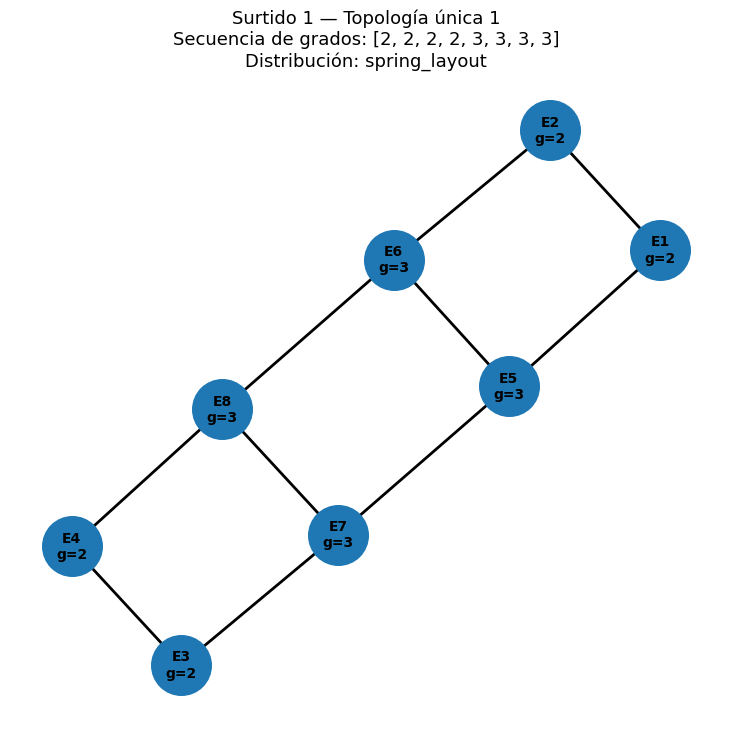

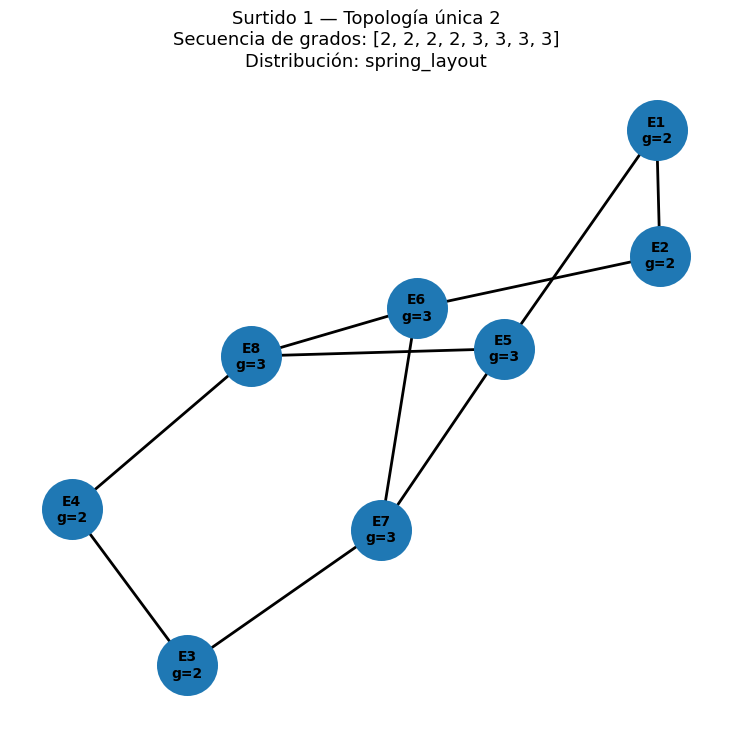

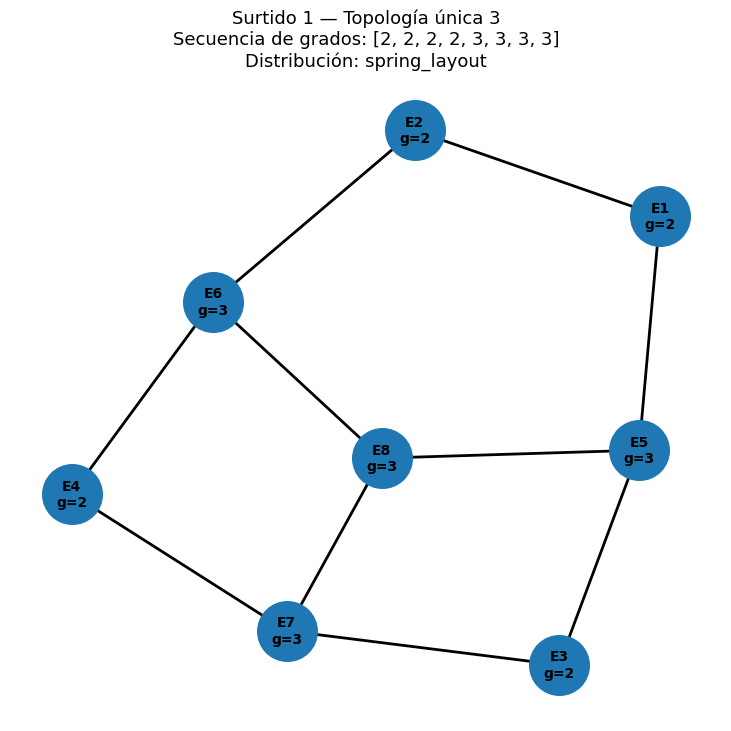

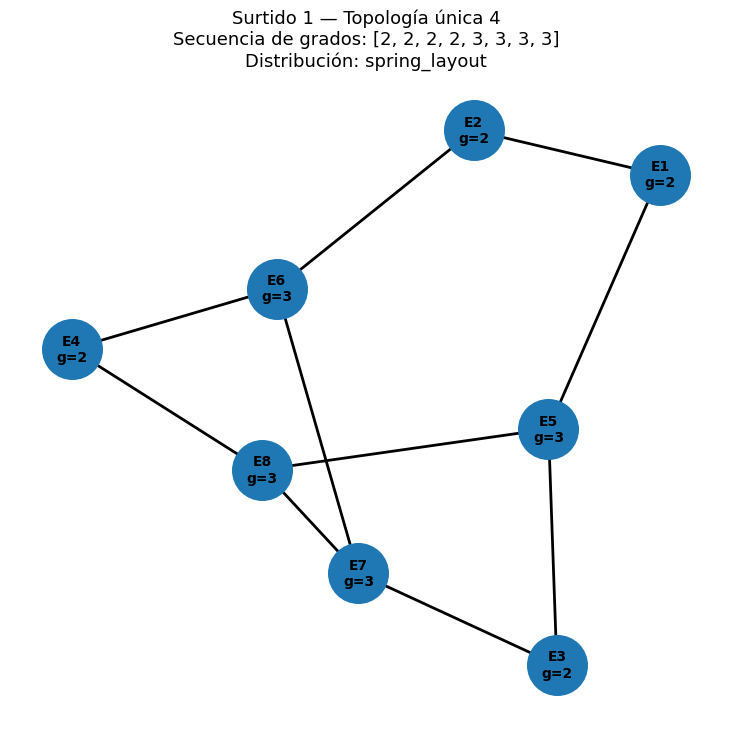

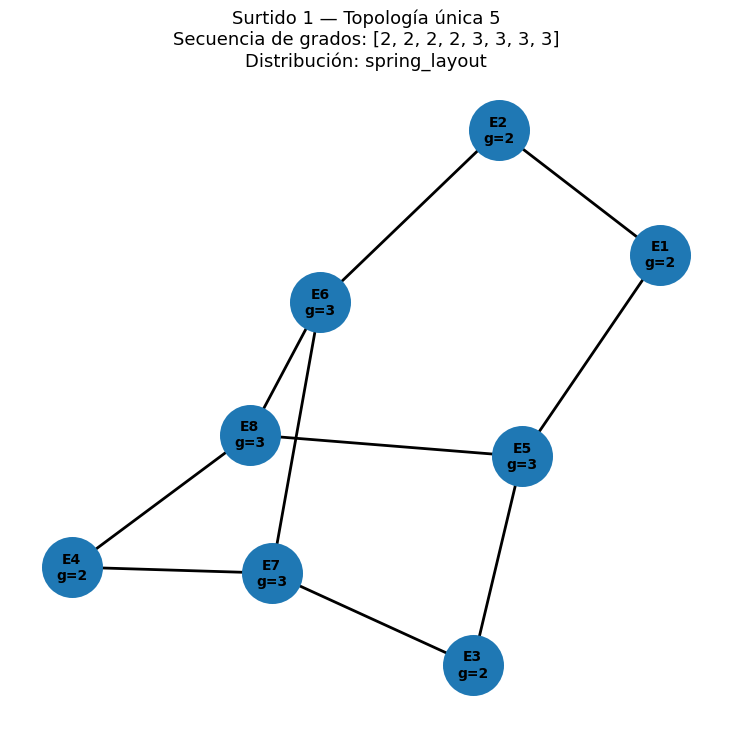

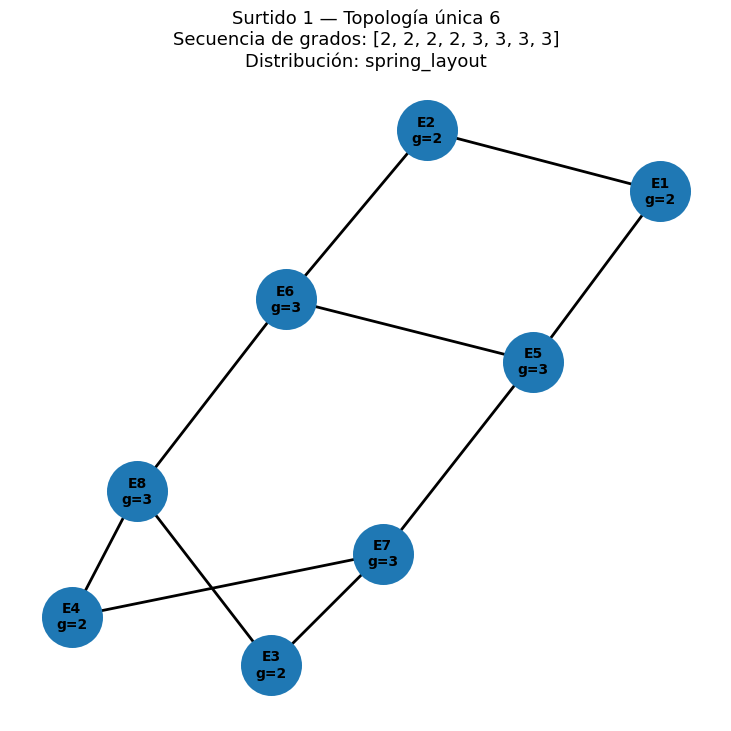

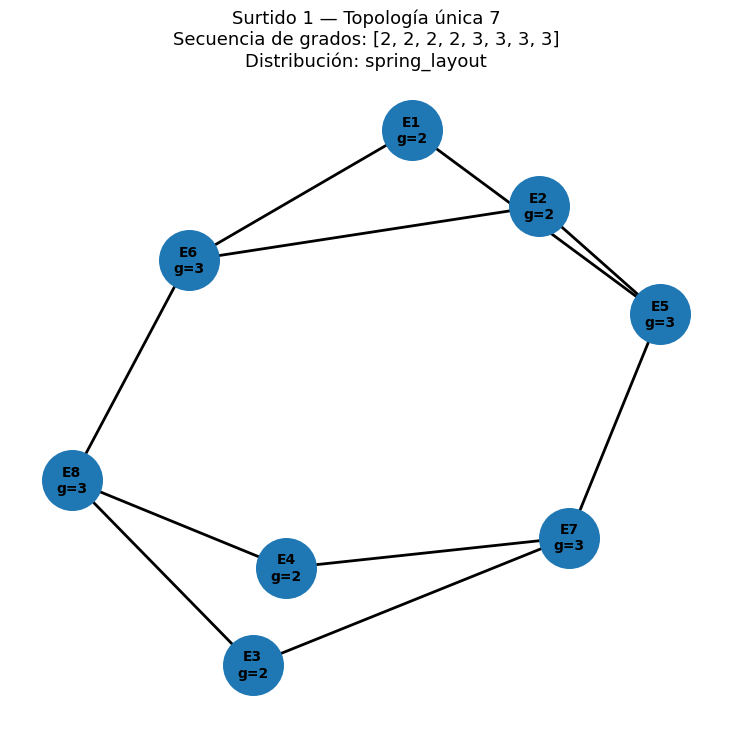

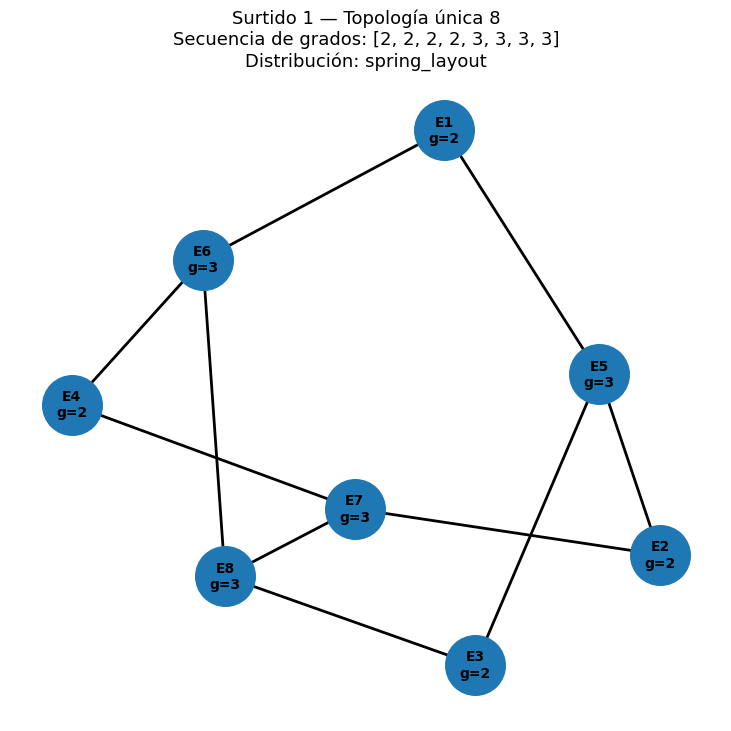

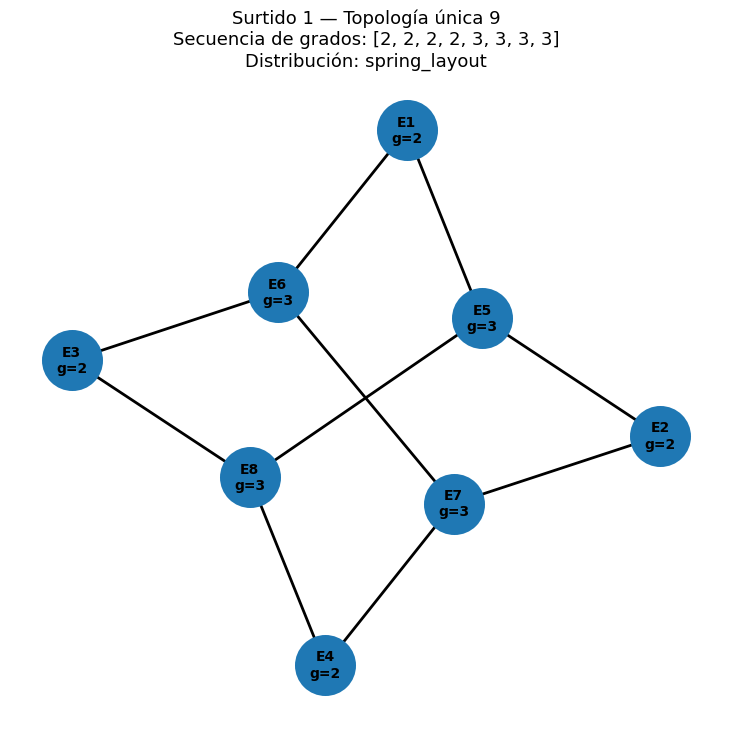

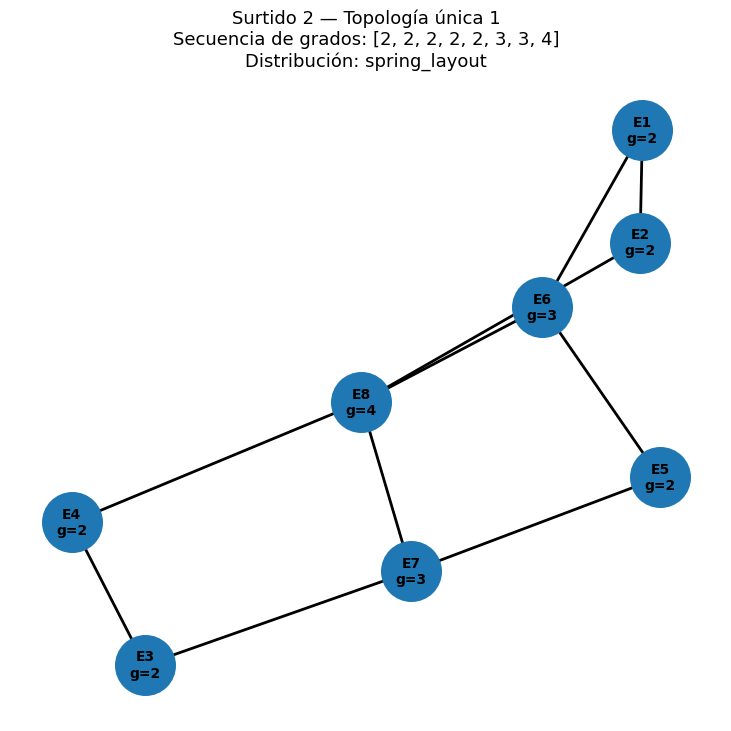

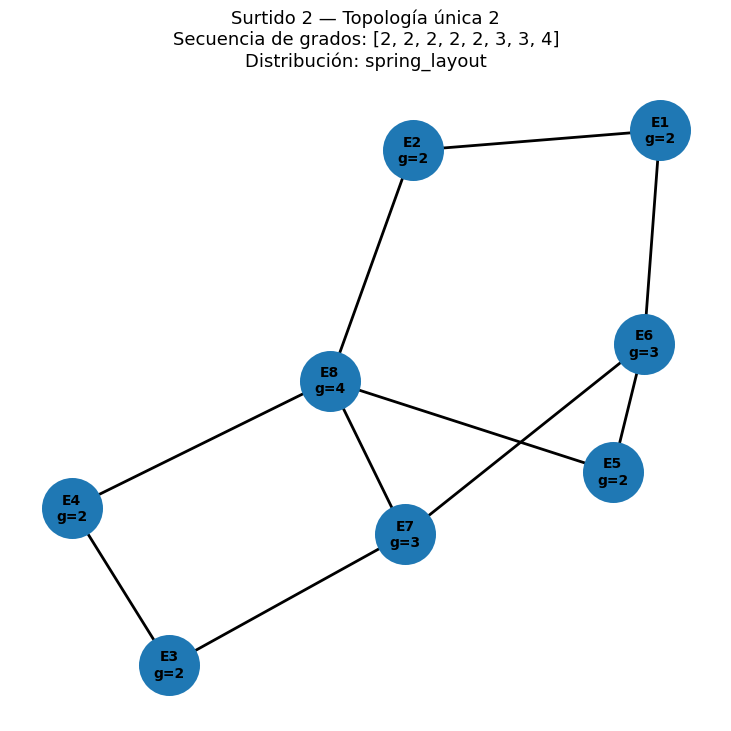

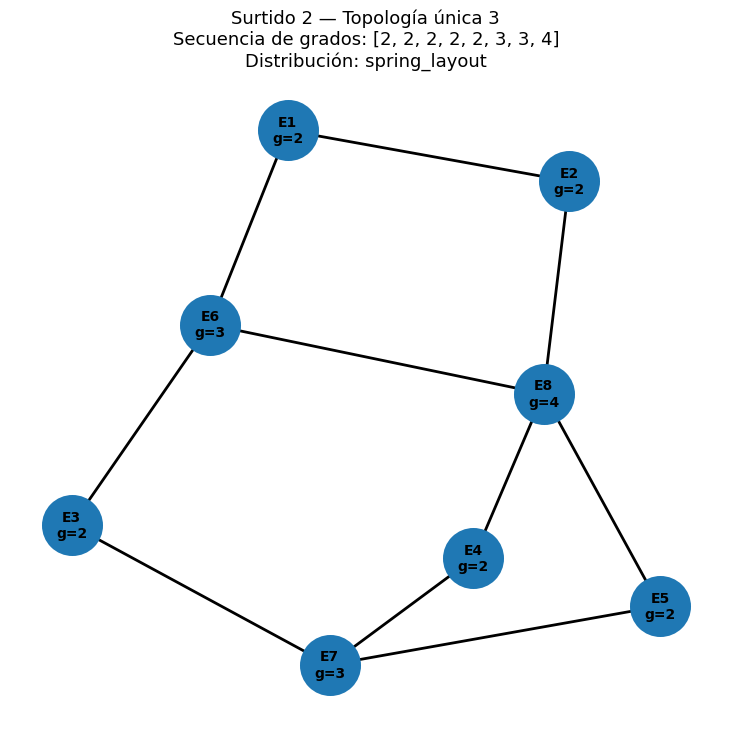

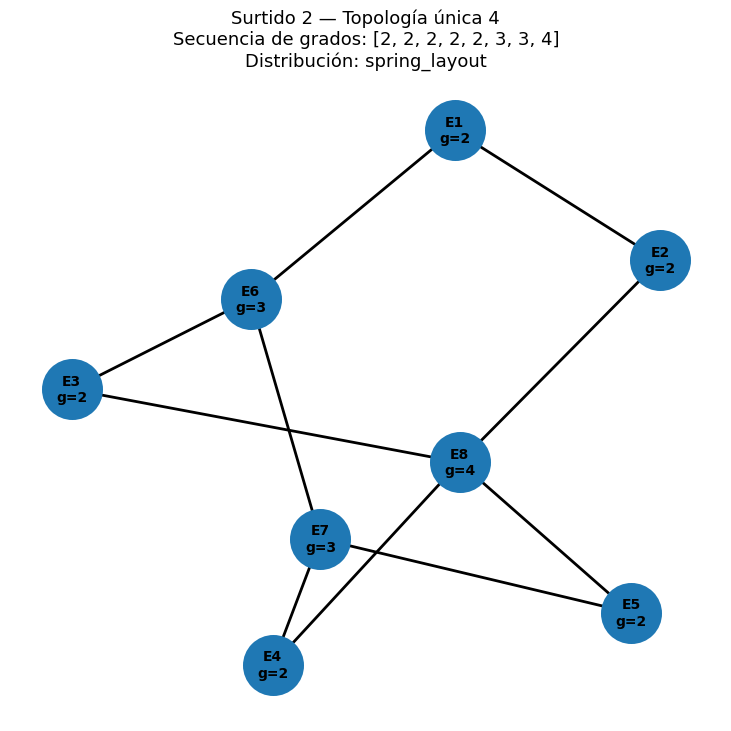

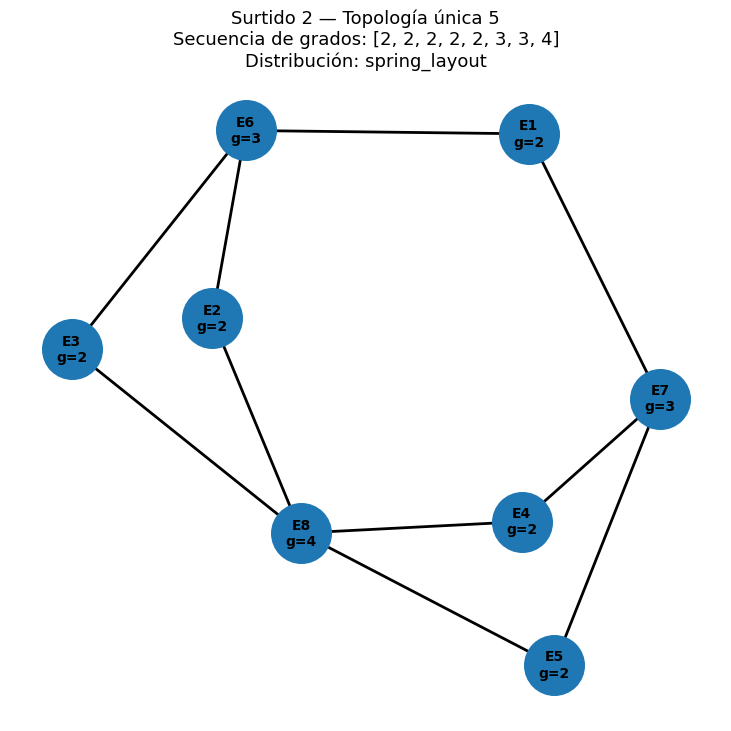

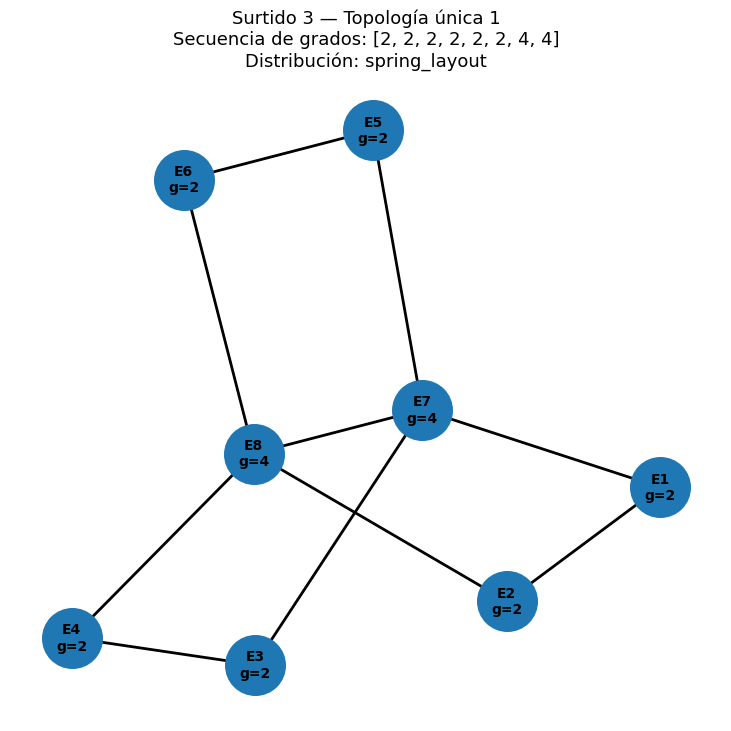

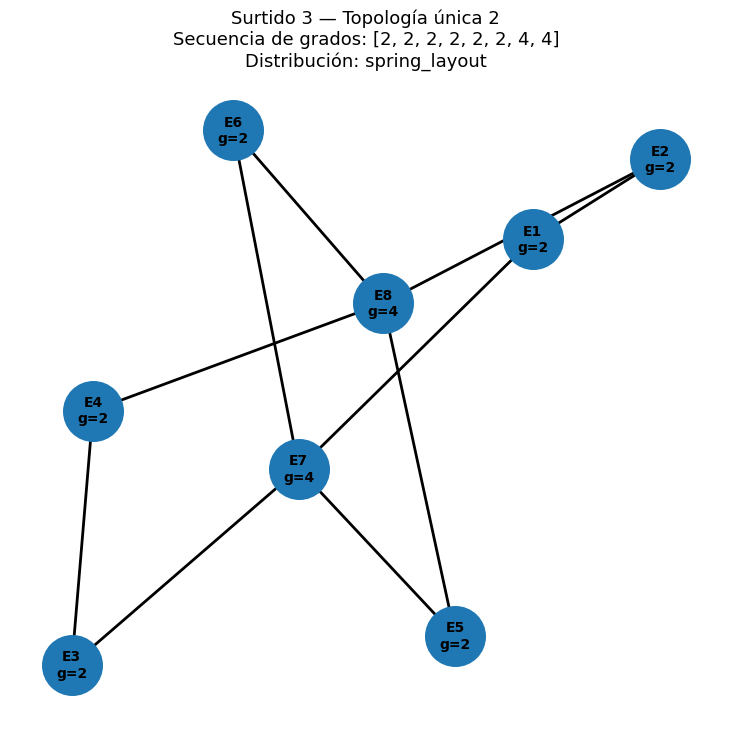


BLOQUE 6
MATRICES FINALES Y DIBUJOS
Topologías procesadas: 16
No se guardaron archivos.

SURTIDO 1
----------------------------------------------------------------------
Secuencia de grados: [2, 2, 2, 2, 3, 3, 3, 3]
Topologías únicas encontradas: 9

TOPOLOGÍA ÚNICA 1
Representante: candidato 343
Cantidad de grafos en la clase: 144
Orden de nodos: [1, 2, 3, 4, 5, 6, 7, 8]
Aristas o juntas: [(1, 2), (1, 5), (2, 6), (3, 4), (3, 7), (4, 8), (5, 6), (5, 7), (6, 8), (7, 8)]
Método usado para el dibujo: spring_layout

Matriz de adyacencia A:
        E1   E2   E3   E4   E5   E6   E7   E8
   E1    0    1    0    0    1    0    0    0
   E2    1    0    0    0    0    1    0    0
   E3    0    0    0    1    0    0    1    0
   E4    0    0    1    0    0    0    0    1
   E5    1    0    0    0    0    1    1    0
   E6    0    1    0    0    1    0    0    1
   E7    0    0    1    0    1    0    0    1
   E8    0    0    0    1    0    1    1    0

Matriz de incidencia B:
             J1(E1-

In [8]:
# ==========================================================
# BLOQUE 6
# MATRICES FINALES Y DIBUJOS EN PANTALLA
# ==========================================================

import matplotlib.pyplot as plt
import networkx as nx


# ==========================================================
# CONFIGURACIÓN DEL BLOQUE 5
# ==========================================================

# Máximo número de topologías que se imprimirán y dibujarán
# por cada surtido.
#
# Usa None para procesar todas.
LIMITE_TOPOLOGIAS_A_MOSTRAR = None

# Semilla para obtener dibujos reproducibles
SEMILLA_DIBUJO = 42

# Mostrar los dibujos en pantalla
MOSTRAR_GRAFICOS = True


# ==========================================================
# MATRIZ DE ADYACENCIA
# ==========================================================

def generar_matriz_adyacencia_final(
    grafo,
    nodos,
):
    """
    Genera la matriz de adyacencia del grafo.

    Las filas y columnas siguen el orden de la lista nodos.
    """

    matriz = []

    for nodo_i in nodos:

        fila = []

        for nodo_j in nodos:

            if grafo.has_edge(nodo_i, nodo_j):
                fila.append(1)
            else:
                fila.append(0)

        matriz.append(fila)

    return matriz


# ==========================================================
# MATRIZ DE INCIDENCIA
# ==========================================================

def generar_matriz_incidencia(
    grafo,
    nodos,
    aristas,
):
    """
    Genera la matriz de incidencia no orientada.

    Filas:
        eslabones.

    Columnas:
        juntas.

    Cada columna contiene exactamente dos unos.
    """

    indice_nodo = {
        nodo: indice
        for indice, nodo in enumerate(nodos)
    }

    numero_eslabones = len(nodos)
    numero_juntas = len(aristas)

    matriz = [
        [0 for _ in range(numero_juntas)]
        for _ in range(numero_eslabones)
    ]

    for indice_junta, (
        eslabon_a,
        eslabon_b,
    ) in enumerate(aristas):

        if not grafo.has_edge(
            eslabon_a,
            eslabon_b,
        ):

            raise ValueError(
                f"La junta ({eslabon_a}, {eslabon_b}) "
                "no existe en el grafo."
            )

        fila_a = indice_nodo[eslabon_a]
        fila_b = indice_nodo[eslabon_b]

        matriz[fila_a][indice_junta] = 1
        matriz[fila_b][indice_junta] = 1

    return matriz


# ==========================================================
# MATRIZ DE GRADOS
# ==========================================================

def generar_matriz_grados(
    grafo,
    nodos,
):
    """
    Genera la matriz diagonal de grados.
    """

    numero_eslabones = len(nodos)

    matriz = [
        [0 for _ in range(numero_eslabones)]
        for _ in range(numero_eslabones)
    ]

    for indice, nodo in enumerate(nodos):

        matriz[indice][indice] = (
            grafo.degree(nodo)
        )

    return matriz


# ==========================================================
# MATRIZ LAPLACIANA
# ==========================================================

def generar_matriz_laplaciana(
    matriz_grados,
    matriz_adyacencia,
):
    """
    Genera la matriz laplaciana:

        L = D - A
    """

    numero_eslabones = len(
        matriz_adyacencia
    )

    return [
        [
            matriz_grados[i][j]
            - matriz_adyacencia[i][j]
            for j in range(numero_eslabones)
        ]
        for i in range(numero_eslabones)
    ]


# ==========================================================
# ETIQUETAS
# ==========================================================

def crear_etiquetas_eslabones(nodos):
    """
    Crea etiquetas:

        E1, E2, E3, ...
    """

    return [
        f"E{nodo}"
        for nodo in nodos
    ]


def crear_etiquetas_juntas(aristas):
    """
    Crea etiquetas como:

        J1(E1-E3)
        J2(E1-E5)
    """

    return [
        f"J{indice}(E{a}-E{b})"
        for indice, (a, b) in enumerate(
            aristas,
            start=1,
        )
    ]


# ==========================================================
# VERIFICACIÓN DE LAS MATRICES
# ==========================================================

def verificar_matrices_finales(
    grafo,
    nodos,
    aristas,
    matriz_adyacencia,
    matriz_incidencia,
    matriz_grados,
    matriz_laplaciana,
):
    """
    Comprueba la consistencia de las matrices generadas.
    """

    numero_eslabones = len(nodos)
    numero_juntas = len(aristas)

    # ------------------------------------------------------
    # Dimensiones
    # ------------------------------------------------------

    assert len(matriz_adyacencia) == (
        numero_eslabones
    )

    assert all(
        len(fila) == numero_eslabones
        for fila in matriz_adyacencia
    )

    assert len(matriz_incidencia) == (
        numero_eslabones
    )

    assert all(
        len(fila) == numero_juntas
        for fila in matriz_incidencia
    )

    assert len(matriz_grados) == (
        numero_eslabones
    )

    assert len(matriz_laplaciana) == (
        numero_eslabones
    )

    # ------------------------------------------------------
    # Matriz de adyacencia
    # ------------------------------------------------------

    for i in range(numero_eslabones):

        assert matriz_adyacencia[i][i] == 0

        for j in range(numero_eslabones):

            assert matriz_adyacencia[i][j] in (
                0,
                1,
            )

            assert (
                matriz_adyacencia[i][j]
                == matriz_adyacencia[j][i]
            )

    # ------------------------------------------------------
    # Grados
    # ------------------------------------------------------

    for indice, nodo in enumerate(nodos):

        grado_grafo = grafo.degree(nodo)

        grado_matriz = sum(
            matriz_adyacencia[indice]
        )

        assert grado_grafo == grado_matriz

        assert (
            matriz_grados[indice][indice]
            == grado_grafo
        )

    # ------------------------------------------------------
    # Incidencia
    # ------------------------------------------------------

    for columna in range(numero_juntas):

        suma_columna = sum(
            matriz_incidencia[fila][columna]
            for fila in range(numero_eslabones)
        )

        assert suma_columna == 2

    for indice, nodo in enumerate(nodos):

        assert (
            sum(matriz_incidencia[indice])
            == grafo.degree(nodo)
        )

    # ------------------------------------------------------
    # Laplaciana
    # ------------------------------------------------------

    for i in range(numero_eslabones):

        for j in range(numero_eslabones):

            assert matriz_laplaciana[i][j] == (
                matriz_grados[i][j]
                - matriz_adyacencia[i][j]
            )

    for fila in matriz_laplaciana:

        assert sum(fila) == 0

    # ------------------------------------------------------
    # Lema del apretón de manos
    # ------------------------------------------------------

    suma_grados = sum(
        grafo.degree(nodo)
        for nodo in nodos
    )

    assert suma_grados == 2 * numero_juntas


# ==========================================================
# IMPRESIÓN FORMATEADA DE MATRICES
# ==========================================================

def imprimir_matriz(
    nombre,
    matriz,
    etiquetas_filas,
    etiquetas_columnas,
):
    """
    Imprime una matriz con encabezados de filas y columnas.
    """

    print()
    print(nombre)

    if not matriz:

        print("  Matriz vacía.")
        return

    todas_las_etiquetas = (
        etiquetas_filas
        + etiquetas_columnas
    )

    ancho = max(
        5,
        max(
            len(str(etiqueta))
            for etiqueta in todas_las_etiquetas
        )
        + 1,
    )

    encabezado = " " * ancho

    encabezado += "".join(
        f"{etiqueta:>{ancho}}"
        for etiqueta in etiquetas_columnas
    )

    print(encabezado)

    for etiqueta, fila in zip(
        etiquetas_filas,
        matriz,
    ):

        valores = "".join(
            f"{valor:>{ancho}}"
            for valor in fila
        )

        print(
            f"{etiqueta:>{ancho}}"
            + valores
        )


# ==========================================================
# POSICIONES DEL GRAFO
# ==========================================================

def calcular_posiciones_grafo(grafo):
    """
    Usa planar_layout cuando el grafo es planar.

    En caso contrario, utiliza spring_layout.
    """

    es_planar, embedding = (
        nx.check_planarity(grafo)
    )

    if es_planar:

        try:

            posiciones = nx.planar_layout(
                grafo,
                embed=embedding,
            )

            return (
                posiciones,
                "planar_layout",
            )

        except Exception:

            pass

    posiciones = nx.spring_layout(
        grafo,
        seed=SEMILLA_DIBUJO,
    )

    return (
        posiciones,
        "spring_layout",
    )


# ==========================================================
# DIBUJAR TOPOLOGÍA
# ==========================================================

def dibujar_topologia(
    grafo,
    numero_surtido,
    numero_topologia,
    secuencia_grados,
):
    """
    Dibuja una topología en pantalla.

    No guarda ningún archivo.
    """

    posiciones, metodo = (
        calcular_posiciones_grafo(grafo)
    )

    etiquetas = {
        nodo: (
            f"E{nodo}\n"
            f"g={grafo.degree(nodo)}"
        )
        for nodo in grafo.nodes()
    }

    lado_figura = max(
        6,
        0.9 * grafo.number_of_nodes(),
    )

    figura, eje = plt.subplots(
        figsize=(
            lado_figura,
            lado_figura,
        ),
        constrained_layout=True,
    )

    nx.draw_networkx_nodes(
        grafo,
        pos=posiciones,
        ax=eje,
        node_size=1800,
        linewidths=1.5,
    )

    nx.draw_networkx_edges(
        grafo,
        pos=posiciones,
        ax=eje,
        width=2,
    )

    nx.draw_networkx_labels(
        grafo,
        pos=posiciones,
        labels=etiquetas,
        ax=eje,
        font_size=10,
        font_weight="bold",
    )

    eje.set_title(
        (
            f"Surtido {numero_surtido} — "
            f"Topología única {numero_topologia}\n"
            f"Secuencia de grados: "
            f"{secuencia_grados}\n"
            f"Distribución: {metodo}"
        ),
        fontsize=13,
    )

    eje.set_axis_off()

    if MOSTRAR_GRAFICOS:

        plt.show()

    plt.close(figura)

    return {
        "metodo_distribucion": metodo,

        "posiciones": {
            int(nodo): [
                float(coordenadas[0]),
                float(coordenadas[1]),
            ]
            for nodo, coordenadas
            in posiciones.items()
        },
    }


# ==========================================================
# PROCESAR UNA TOPOLOGÍA
# ==========================================================

def procesar_topologia_final(
    topologia,
    surtido,
    numero_surtido,
):
    """
    Genera las matrices finales y dibuja una topología.

    No crea ni guarda archivos.
    """

    numero_topologia = topologia[
        "numero_topologia_unica"
    ]

    # ------------------------------------------------------
    # Obtener o reconstruir el grafo
    # ------------------------------------------------------

    grafo = topologia.get(
        "grafo_networkx"
    )

    if grafo is None:

        grafo = crear_grafo_networkx(
            matriz_adyacencia=(
                topologia[
                    "matriz_adyacencia"
                ]
            ),
            grados_objetivo=(
                surtido["grados_links"]
            ),
        )

        topologia[
            "grafo_networkx"
        ] = grafo

    nodos = sorted(
        grafo.nodes()
    )

    aristas = sorted(
        tuple(sorted(arista))
        for arista in grafo.edges()
    )

    # ------------------------------------------------------
    # Generar matrices
    # ------------------------------------------------------

    matriz_adyacencia = (
        generar_matriz_adyacencia_final(
            grafo=grafo,
            nodos=nodos,
        )
    )

    matriz_incidencia = (
        generar_matriz_incidencia(
            grafo=grafo,
            nodos=nodos,
            aristas=aristas,
        )
    )

    matriz_grados = generar_matriz_grados(
        grafo=grafo,
        nodos=nodos,
    )

    matriz_laplaciana = (
        generar_matriz_laplaciana(
            matriz_grados=matriz_grados,
            matriz_adyacencia=(
                matriz_adyacencia
            ),
        )
    )

    # ------------------------------------------------------
    # Verificar matrices
    # ------------------------------------------------------

    verificar_matrices_finales(
        grafo=grafo,
        nodos=nodos,
        aristas=aristas,
        matriz_adyacencia=matriz_adyacencia,
        matriz_incidencia=matriz_incidencia,
        matriz_grados=matriz_grados,
        matriz_laplaciana=matriz_laplaciana,
    )

    etiquetas_eslabones = (
        crear_etiquetas_eslabones(nodos)
    )

    etiquetas_juntas = (
        crear_etiquetas_juntas(aristas)
    )

    # ------------------------------------------------------
    # Dibujar
    # ------------------------------------------------------

    informacion_dibujo = dibujar_topologia(
        grafo=grafo,
        numero_surtido=numero_surtido,
        numero_topologia=numero_topologia,
        secuencia_grados=(
            surtido["grados_links"]
        ),
    )

    # ------------------------------------------------------
    # Guardar únicamente en memoria
    # ------------------------------------------------------

    representacion_final = {
        "orden_nodos": nodos,
        "orden_aristas": aristas,

        "etiquetas_eslabones": (
            etiquetas_eslabones
        ),

        "etiquetas_juntas": (
            etiquetas_juntas
        ),

        "matriz_adyacencia": (
            matriz_adyacencia
        ),

        "matriz_incidencia": (
            matriz_incidencia
        ),

        "matriz_grados": (
            matriz_grados
        ),

        "matriz_laplaciana": (
            matriz_laplaciana
        ),

        "informacion_dibujo": (
            informacion_dibujo
        ),
    }

    topologia[
        "representacion_final"
    ] = representacion_final

    return representacion_final


# ==========================================================
# EJECUCIÓN DEL BLOQUE 6
# ==========================================================

total_topologias_procesadas = 0

for numero_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    representaciones_finales = []

    topologias = surtido.get(
        "topologias_unicas",
        [],
    )

    if LIMITE_TOPOLOGIAS_A_MOSTRAR is None:

        topologias_a_procesar = topologias

    else:

        topologias_a_procesar = topologias[
            :LIMITE_TOPOLOGIAS_A_MOSTRAR
        ]

    for topologia in topologias_a_procesar:

        representacion = (
            procesar_topologia_final(
                topologia=topologia,
                surtido=surtido,
                numero_surtido=numero_surtido,
            )
        )

        representaciones_finales.append(
            representacion
        )

        total_topologias_procesadas += 1

    surtido[
        "representaciones_finales"
    ] = representaciones_finales

    surtido[
        "numero_representaciones_finales"
    ] = len(representaciones_finales)


# ==========================================================
# RESUMEN GENERAL
# ==========================================================

print()
print("=" * 70)
print("BLOQUE 6")
print("MATRICES FINALES Y DIBUJOS")
print("=" * 70)

print(
    f"Topologías procesadas: "
    f"{total_topologias_procesadas}"
)

print(
    "No se guardaron archivos."
)

print("=" * 70)


# ==========================================================
# IMPRESIÓN DE RESULTADOS
# ==========================================================

for numero_surtido, surtido in enumerate(
    surtidos_encontrados,
    start=1,
):

    print()
    print(f"SURTIDO {numero_surtido}")
    print("-" * 70)

    print(
        f"Secuencia de grados: "
        f"{surtido['grados_links']}"
    )

    print(
        f"Topologías únicas encontradas: "
        f"{surtido.get('numero_topologias_unicas', 0)}"
    )

    topologias = surtido.get(
        "topologias_unicas",
        [],
    )

    if LIMITE_TOPOLOGIAS_A_MOSTRAR is None:

        topologias_a_imprimir = topologias

    else:

        topologias_a_imprimir = topologias[
            :LIMITE_TOPOLOGIAS_A_MOSTRAR
        ]

    for topologia in topologias_a_imprimir:

        numero_topologia = topologia[
            "numero_topologia_unica"
        ]

        representacion = topologia[
            "representacion_final"
        ]

        etiquetas_eslabones = (
            representacion[
                "etiquetas_eslabones"
            ]
        )

        etiquetas_juntas = (
            representacion[
                "etiquetas_juntas"
            ]
        )

        print()
        print("=" * 70)

        print(
            f"TOPOLOGÍA ÚNICA "
            f"{numero_topologia}"
        )

        print("=" * 70)

        print(
            f"Representante: candidato "
            f"{topologia['numero']}"
        )

        print(
            f"Cantidad de grafos en la clase: "
            f"{topologia['cantidad_grafos_clase']}"
        )

        print(
            f"Orden de nodos: "
            f"{representacion['orden_nodos']}"
        )

        print(
            f"Aristas o juntas: "
            f"{representacion['orden_aristas']}"
        )

        print(
            f"Método usado para el dibujo: "
            f"{representacion['informacion_dibujo']['metodo_distribucion']}"
        )

        # --------------------------------------------------
        # Matriz de adyacencia
        # --------------------------------------------------

        imprimir_matriz(
            nombre="Matriz de adyacencia A:",
            matriz=representacion[
                "matriz_adyacencia"
            ],
            etiquetas_filas=(
                etiquetas_eslabones
            ),
            etiquetas_columnas=(
                etiquetas_eslabones
            ),
        )

        # --------------------------------------------------
        # Matriz de incidencia
        # --------------------------------------------------

        imprimir_matriz(
            nombre="Matriz de incidencia B:",
            matriz=representacion[
                "matriz_incidencia"
            ],
            etiquetas_filas=(
                etiquetas_eslabones
            ),
            etiquetas_columnas=(
                etiquetas_juntas
            ),
        )

        # --------------------------------------------------
        # Matriz de grados
        # --------------------------------------------------

        imprimir_matriz(
            nombre="Matriz de grados D:",
            matriz=representacion[
                "matriz_grados"
            ],
            etiquetas_filas=(
                etiquetas_eslabones
            ),
            etiquetas_columnas=(
                etiquetas_eslabones
            ),
        )

        # --------------------------------------------------
        # Matriz laplaciana
        # --------------------------------------------------

        imprimir_matriz(
            nombre=(
                "Matriz laplaciana L = D - A:"
            ),
            matriz=representacion[
                "matriz_laplaciana"
            ],
            etiquetas_filas=(
                etiquetas_eslabones
            ),
            etiquetas_columnas=(
                etiquetas_eslabones
            ),
        )

    numero_no_procesado = (
        len(topologias)
        - len(topologias_a_imprimir)
    )

    if numero_no_procesado > 0:

        print()
        print(
            f"No se muestran "
            f"{numero_no_procesado} "
            "topologías adicionales."
        )

    print()
    print("=" * 70)

CONTEO DE SURTIDOS DE ESLABONES
    n       J        Grados permitidos       Número de surtidos
---------------------------------------------------------------------------
    4       4                    2 a 2                        1
    6       7                    2 a 3                        1
    8      10                    2 a 4                        3
   10      13                    2 a 5                        7
   12      16                    2 a 6                       15
   14      19                    2 a 7                       30
   16      22                    2 a 8                       58
   18      25                    2 a 9                      105
   20      28                   2 a 10                      186
   22      31                   2 a 11                      318
   24      34                   2 a 12                      530
   26      37                   2 a 13                      863
   28      40                   2 a 14                     1

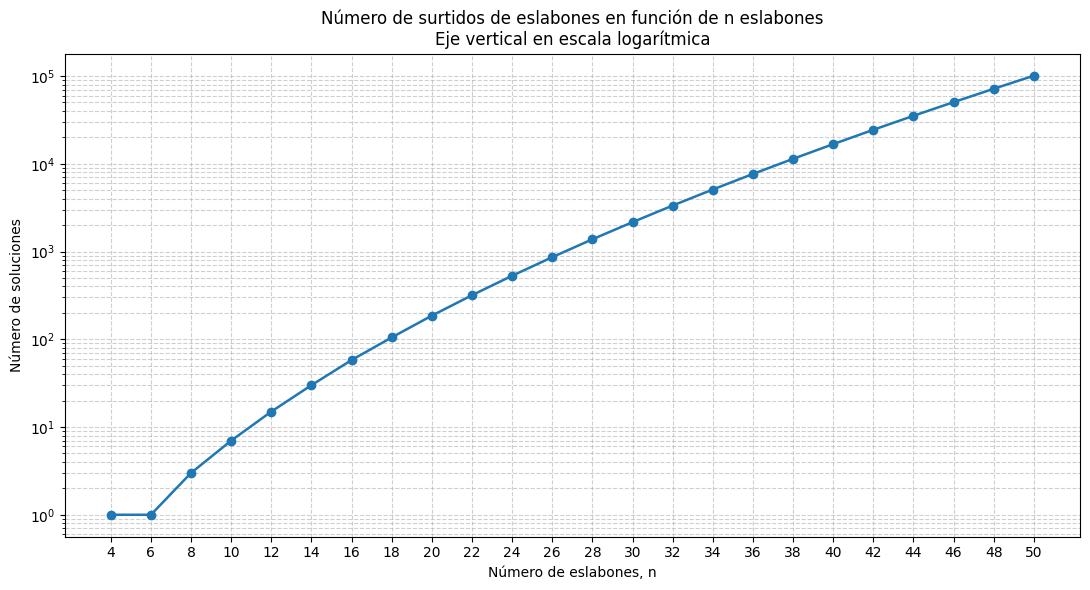

In [10]:
# ==========================================================
# CONTEO DE SURTIDOS DE ESLABONES PARA DIFERENTES VALORES DE n
# ==========================================================

import matplotlib.pyplot as plt


# ----------------------------------------------------------
# CONFIGURACIÓN GENERAL
# ----------------------------------------------------------

GDL = 1

# Valores pares de n desde 4 hasta 50
valores_n = list(range(4, 51, 2))


# ==========================================================
# CÁLCULO DEL NÚMERO DE JUNTAS
# ==========================================================

def calcular_numero_juntas(n, gdl=1):
    """
    Calcula el número de juntas J mediante la ecuación de
    movilidad de Grübler-Kutzbach para mecanismos planos
    con pares inferiores:

        GDL = 3(n - 1) - 2J

    Por tanto:

        J = [3(n - 1) - GDL] / 2

    Retorna None cuando J no es entero.
    """

    numerador = 3 * (n - 1) - gdl

    if numerador % 2 != 0:
        return None

    return numerador // 2


# ==========================================================
# CONTEO DE SOLUCIONES MEDIANTE PROGRAMACIÓN DINÁMICA
# ==========================================================

def contar_surtidos(n, gdl=1):
    """
    Cuenta las soluciones enteras no negativas de:

        sum(x_g) = n
        sum(g * x_g) = 2J

    donde:

        g = 2, 3, ..., n // 2

    y x_g representa la cantidad de eslabones de grado g.

    La función cuenta cada surtido una sola vez.
    No genera permutaciones ni construye individualmente
    los eslabones.
    """

    J = calcular_numero_juntas(n, gdl)

    if J is None:
        return 0

    objetivo_eslabones = n
    objetivo_grados = 2 * J

    grados_posibles = range(2, n // 2 + 1)

    # dp[cantidad_eslabones][suma_grados]
    # representa cuántos surtidos pueden construirse.
    dp = [
        [0] * (objetivo_grados + 1)
        for _ in range(objetivo_eslabones + 1)
    ]

    # Caso inicial: cero eslabones y suma de grados cero
    dp[0][0] = 1

    # Cada grado se procesa una sola vez.
    # El recorrido ascendente permite emplear cualquier
    # cantidad de eslabones de ese grado.
    for grado in grados_posibles:

        for cantidad_eslabones in range(
            1,
            objetivo_eslabones + 1,
        ):
            for suma_grados in range(
                grado,
                objetivo_grados + 1,
            ):
                dp[cantidad_eslabones][suma_grados] += (
                    dp[
                        cantidad_eslabones - 1
                    ][
                        suma_grados - grado
                    ]
                )

    return dp[objetivo_eslabones][objetivo_grados]


# ==========================================================
# EVALUACIÓN PARA TODOS LOS VALORES DE n
# ==========================================================

resultados = []

print("=" * 75)
print("CONTEO DE SURTIDOS DE ESLABONES")
print("=" * 75)

print(
    f"{'n':>5}"
    f"{'J':>8}"
    f"{'Grados permitidos':>25}"
    f"{'Número de surtidos':>25}"
)

print("-" * 75)

for n in valores_n:

    J = calcular_numero_juntas(n, GDL)
    numero_surtidos = contar_surtidos(n, GDL)

    resultados.append(numero_surtidos)

    grados = f"2 a {n // 2}"

    print(
        f"{n:>5}"
        f"{J:>8}"
        f"{grados:>25}"
        f"{numero_surtidos:>25}"
    )

print("=" * 75)


# ==========================================================
# GRÁFICA EN ESCALA LOGARÍTMICA
# ==========================================================

plt.figure(figsize=(11, 6))

plt.plot(
    valores_n,
    resultados,
    marker="o",
    linewidth=1.8,
)

# Escala logarítmica únicamente en el eje y
plt.yscale("log")

plt.xlabel("Número de eslabones, n")
plt.ylabel("Número de soluciones")
plt.title(
    "Número de surtidos de eslabones en función de n eslabones\n"
    "Eje vertical en escala logarítmica"
)

plt.xticks(valores_n)
plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.6,
)

plt.tight_layout()
plt.show()